# SDV Models: Comprehensive Evaluation - AD Dataset

This notebook contains a comprehensive evaluation of four synthetic data generation models on the Alzheimer's Disease (AD) dataset:
1. **CopulaGAN** - GAN-based with copula modeling
2. **Gaussian Copula** - Statistical copula-based approach
3. **CTGAN** - Conditional Tabular GAN
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## 1. Data Loading and Setup


In [1]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data (walk up from notebook cwd → repo Datasets/)
_here = Path.cwd().resolve()
_roots = [_here, *_here.parents]
candidate_names = ["Alzhimers.xlsx", "Alzheimer.xlsx", "Alzheimer.csv", "clean_alzheimer.csv"]
candidate_paths = []
for root in _roots:
    for name in candidate_names:
        candidate_paths.append(root / "Datasets" / name)
        candidate_paths.append(root / name)
    candidate_paths.append(root / "Synthetic_Data_Audit" / "Datasets" / "Alzhimers.xlsx")

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    ds_dir = next((r / "Datasets" for r in _roots if (r / "Datasets").is_dir()), None)
    available = sorted(p.name for p in ds_dir.glob("*")) if ds_dir else []
    raise FileNotFoundError(
        "Alzheimer dataset file not found. Expected Datasets/Alzhimers.xlsx under the repo root. "
        f"Available dataset files: {available}"
    )
print(f"Loading: {data_path}")

ad_data = pd.read_excel(data_path)

# Keep Subject ID until after the participant-level split.
ad_data = ad_data.drop(columns=["M/F", "MRI ID", "Hand"], errors="ignore")
if "Subject ID" not in ad_data.columns:
    raise KeyError("Subject ID is required for participant-level train/test splits")

ad_data["Group"] = ad_data["Group"].replace(
    {"Demented": 1, "Nondemented": 0, "Converted": 1}
)

# Avoid imputation (no mean / median / mode fill). Complete-case only.
_before = len(ad_data)
_n_missing_rows = int(ad_data.isna().any(axis=1).sum())
ad_data = ad_data.dropna().reset_index(drop=True)
print(
    f"Dropped {_before - len(ad_data)} rows with missing feature values "
    f"(complete-case; no imputation; rows_with_na={_n_missing_rows})"
)
assert not ad_data.isna().any().any(), "Unexpected NaNs remain after dropna"

def _participant_split(df, subject_col="Subject ID", label_col="Group", test_size=0.2, seed=42):
    """Split by Subject ID so all sessions of a participant stay in one fold."""
    if subject_col not in df.columns:
        raise KeyError(f"{subject_col} required for participant-level split")
    subj_label = df.groupby(subject_col)[label_col].first()
    subjects = subj_label.index.to_numpy()
    subj_y = subj_label.to_numpy()
    from sklearn.model_selection import train_test_split
    subj_train, subj_test = train_test_split(
        subjects, test_size=test_size, random_state=seed, stratify=subj_y
    )
    assert set(subj_train).isdisjoint(set(subj_test)), "Subject overlap between train and test"
    train_df = (
        df[df[subject_col].isin(subj_train)]
        .drop(columns=[subject_col])
        .reset_index(drop=True)
    )
    test_df = (
        df[df[subject_col].isin(subj_test)]
        .drop(columns=[subject_col])
        .reset_index(drop=True)
    )
    print(
        f"Participant split: subjects={len(subjects)} "
        f"(train={len(subj_train)}, test={len(subj_test)}); "
        f"sessions train={len(train_df)}, test={len(test_df)}"
    )
    print("Train Group:", train_df[label_col].value_counts().to_dict())
    print("Test Group:", test_df[label_col].value_counts().to_dict())
    return train_df, test_df

train_real, test_real = _participant_split(ad_data)

# Generators / fidelity use train subjects only (leak-safe).
ad_data = train_real.copy()
print("Data cleaned successfully!")
print(ad_data.head())

# Detect Metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(ad_data)
print(f"Metadata detected. Columns found: {len(ad_data.columns)}")


Loading: /home/gopi.battineni/SYNTH_BENCHMARK/SYNTH/Datasets/Alzhimers.xlsx
Dropped 19 rows with missing feature values (complete-case; no imputation; rows_with_na=19)
Participant split: subjects=142 (train=113, test=29); sessions train=284, test=70
Train Group: {0: 151, 1: 133}
Test Group: {0: 39, 1: 31}
Data cleaned successfully!
   Group  Visit  MR Delay  Age  EDUC  SES  MMSE  CDR         eTIV      nWBV  \
0      0      1         0   87    14  2.0  27.0  0.0  1986.550000  0.696106   
1      0      2       457   88    14  2.0  30.0  0.0  2004.479526  0.681062   
2      0      1         0   93    14  2.0  30.0  0.0  1271.510000  0.697599   
3      0      2       742   95    14  2.0  29.0  0.0  1257.350000  0.703206   
4      1      1         0   66    12  3.0  30.0  0.5  1446.660000  0.768708   

        ASF  
0  0.883440  
1  0.875539  
2  1.380240  
3  1.395790  
4  1.213140  
Metadata detected. Columns found: 11


# 2. Generating Synthetic data for Four SDV Models

In [2]:
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
import pandas as pd

# Use the dataset you loaded in this notebook
real_data = ad_data.copy()

# Number of synthetic rows to generate per model
n_samples = 1000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(real_data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 1667.84it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 310.09it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 313.73it/s]|
Column Shapes Score: 81.5%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 231.94it/s]|
Column Pair Trends Score: 59.34%

Overall Score (Average): 70.42%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 1676.69it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 489.82it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 223.16it/s]|
Column Shapes Score: 79.39%

(2/2) E

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.814295
1,TVAE,1.0,0.769952
2,CTGAN,1.0,0.704188
3,CopulaGAN,1.0,0.697823



Best model by quality score: GaussianCopula


,Group,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,0,2,11,81,15,2.0,29.0,0.0,1781.866021,0.712995,0.983698
1,0,1,0,71,15,3.0,30.0,0.0,1194.099024,0.765192,1.469021
2,0,1,0,65,14,1.0,30.0,0.0,1568.791680,0.771664,1.115130
3,1,3,44,84,16,3.0,24.0,0.1,1326.534145,0.670489,1.328123
4,0,1,0,71,15,1.0,29.0,0.0,1501.525274,0.730101,1.170549


# 1. Univariate Analysis
#### 1.1. Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 306.89it/s]|
Column Shapes Score: 81.5%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 182.19it/s]|
Column Pair Trends Score: 59.34%

Overall Score (Average): 70.42%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 572.47it/s]|
Column Shapes Score: 79.39%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 271.60it/s]|
Column Pair Trends Score: 60.18%

Overall Score (Average): 69.78%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 619.00it/s]|
Column Shapes Score: 82.99%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 251.04it/s]|
Column Pair Trends Score: 71.0%

Overall Score (Average): 77.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 645.58it/s]|
Column Shapes Score: 87.75%

(2/2) Evaluating Column Pair Tren

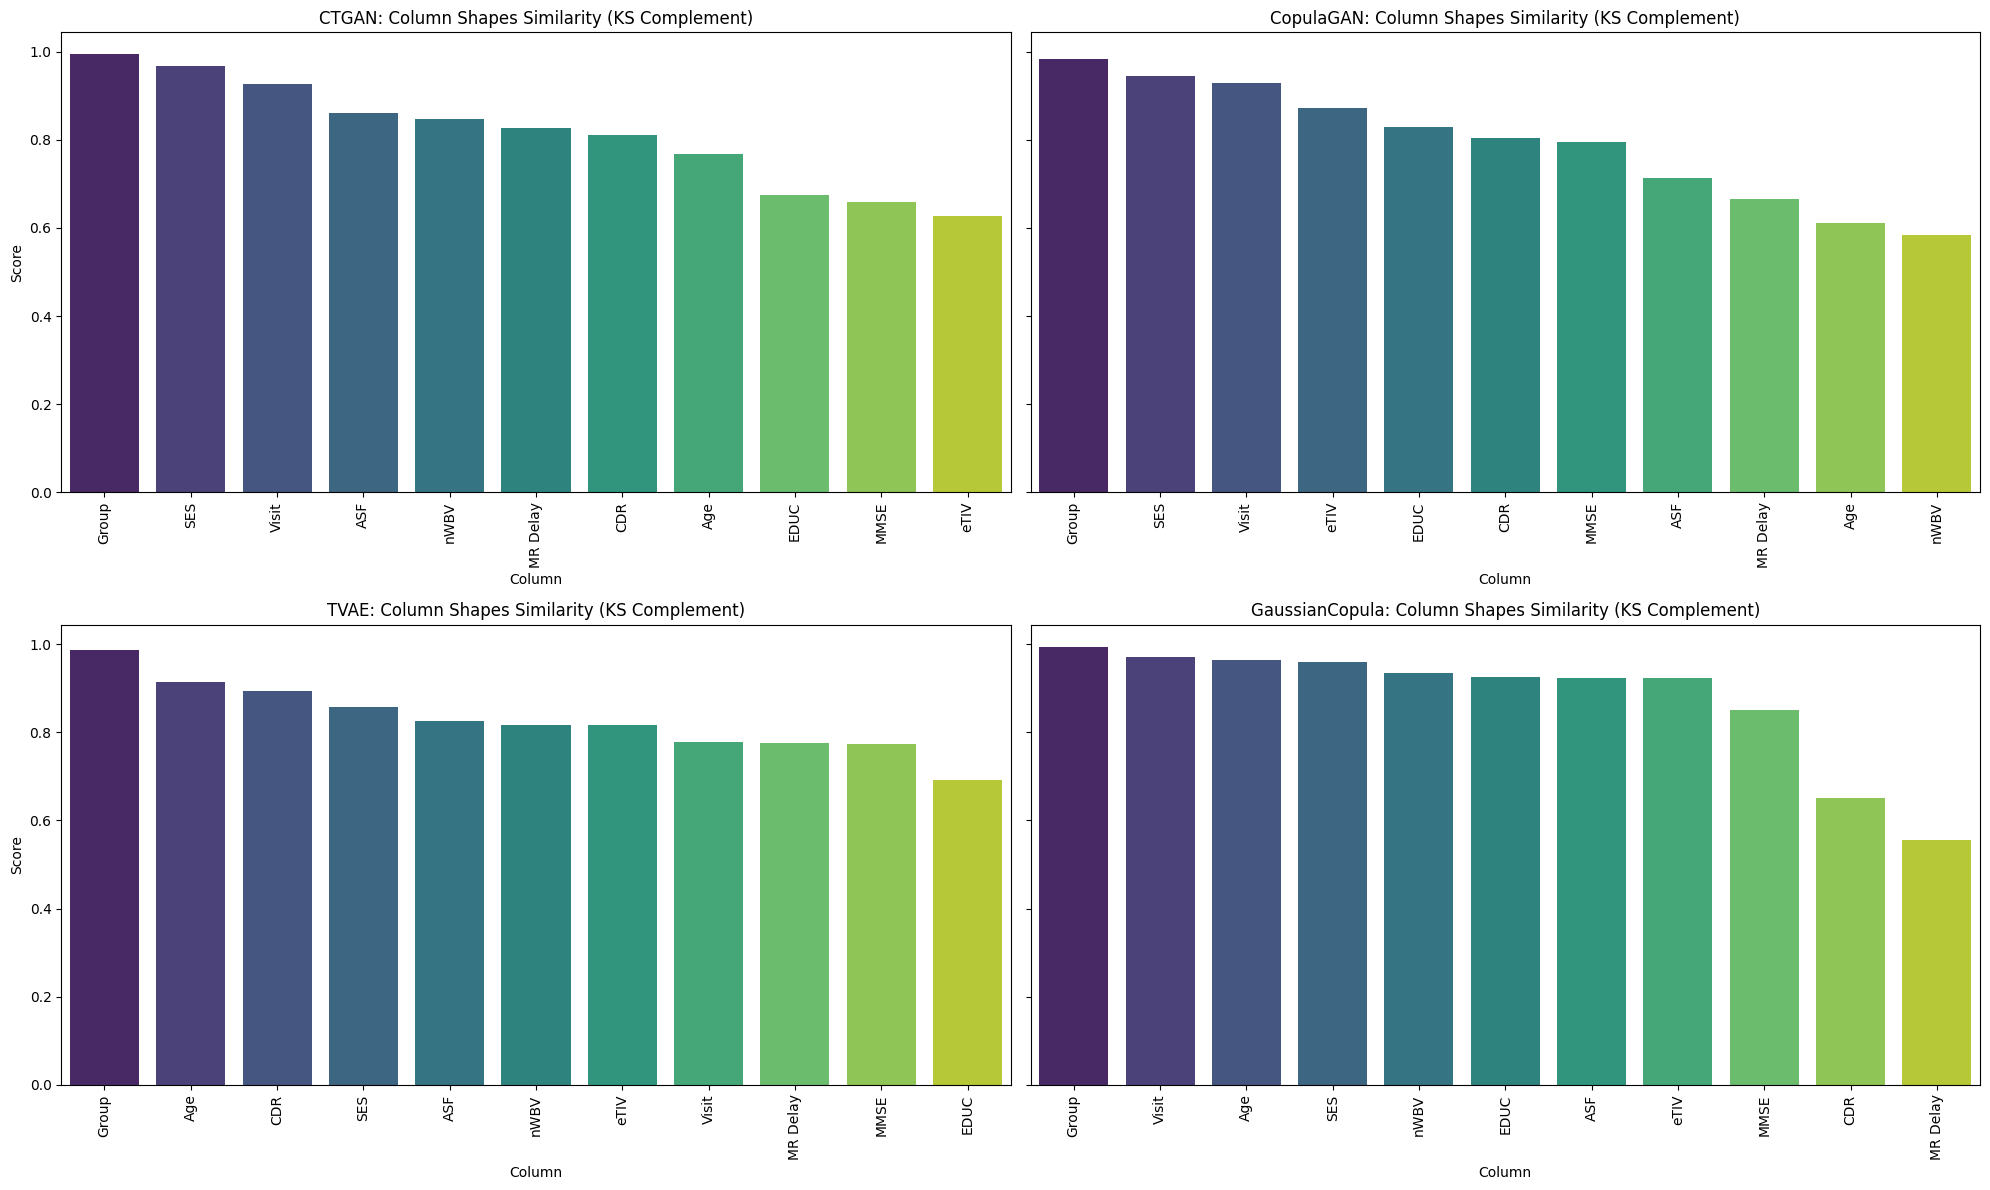

,Column,Metric,Score,Model
0,Group,TVComplement,0.994310,CTGAN
1,SES,TVComplement,0.967479,CTGAN
2,Visit,TVComplement,0.927718,CTGAN
3,ASF,KSComplement,0.860197,CTGAN
4,nWBV,KSComplement,0.846775,CTGAN
5,MR Delay,KSComplement,0.826113,CTGAN
6,CDR,KSComplement,0.811451,CTGAN
7,Age,KSComplement,0.768254,CTGAN
8,EDUC,KSComplement,0.674831,CTGAN
9,MMSE,KSComplement,0.659408,CTGAN


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
column_shape_details = {}

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=real_data,
        synthetic_data=synthetic_datasets[model_name],
        metadata=metadata.to_dict()
    )
    details = qr.get_details(property_name="Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

#### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()
    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)
    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]
        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)
        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

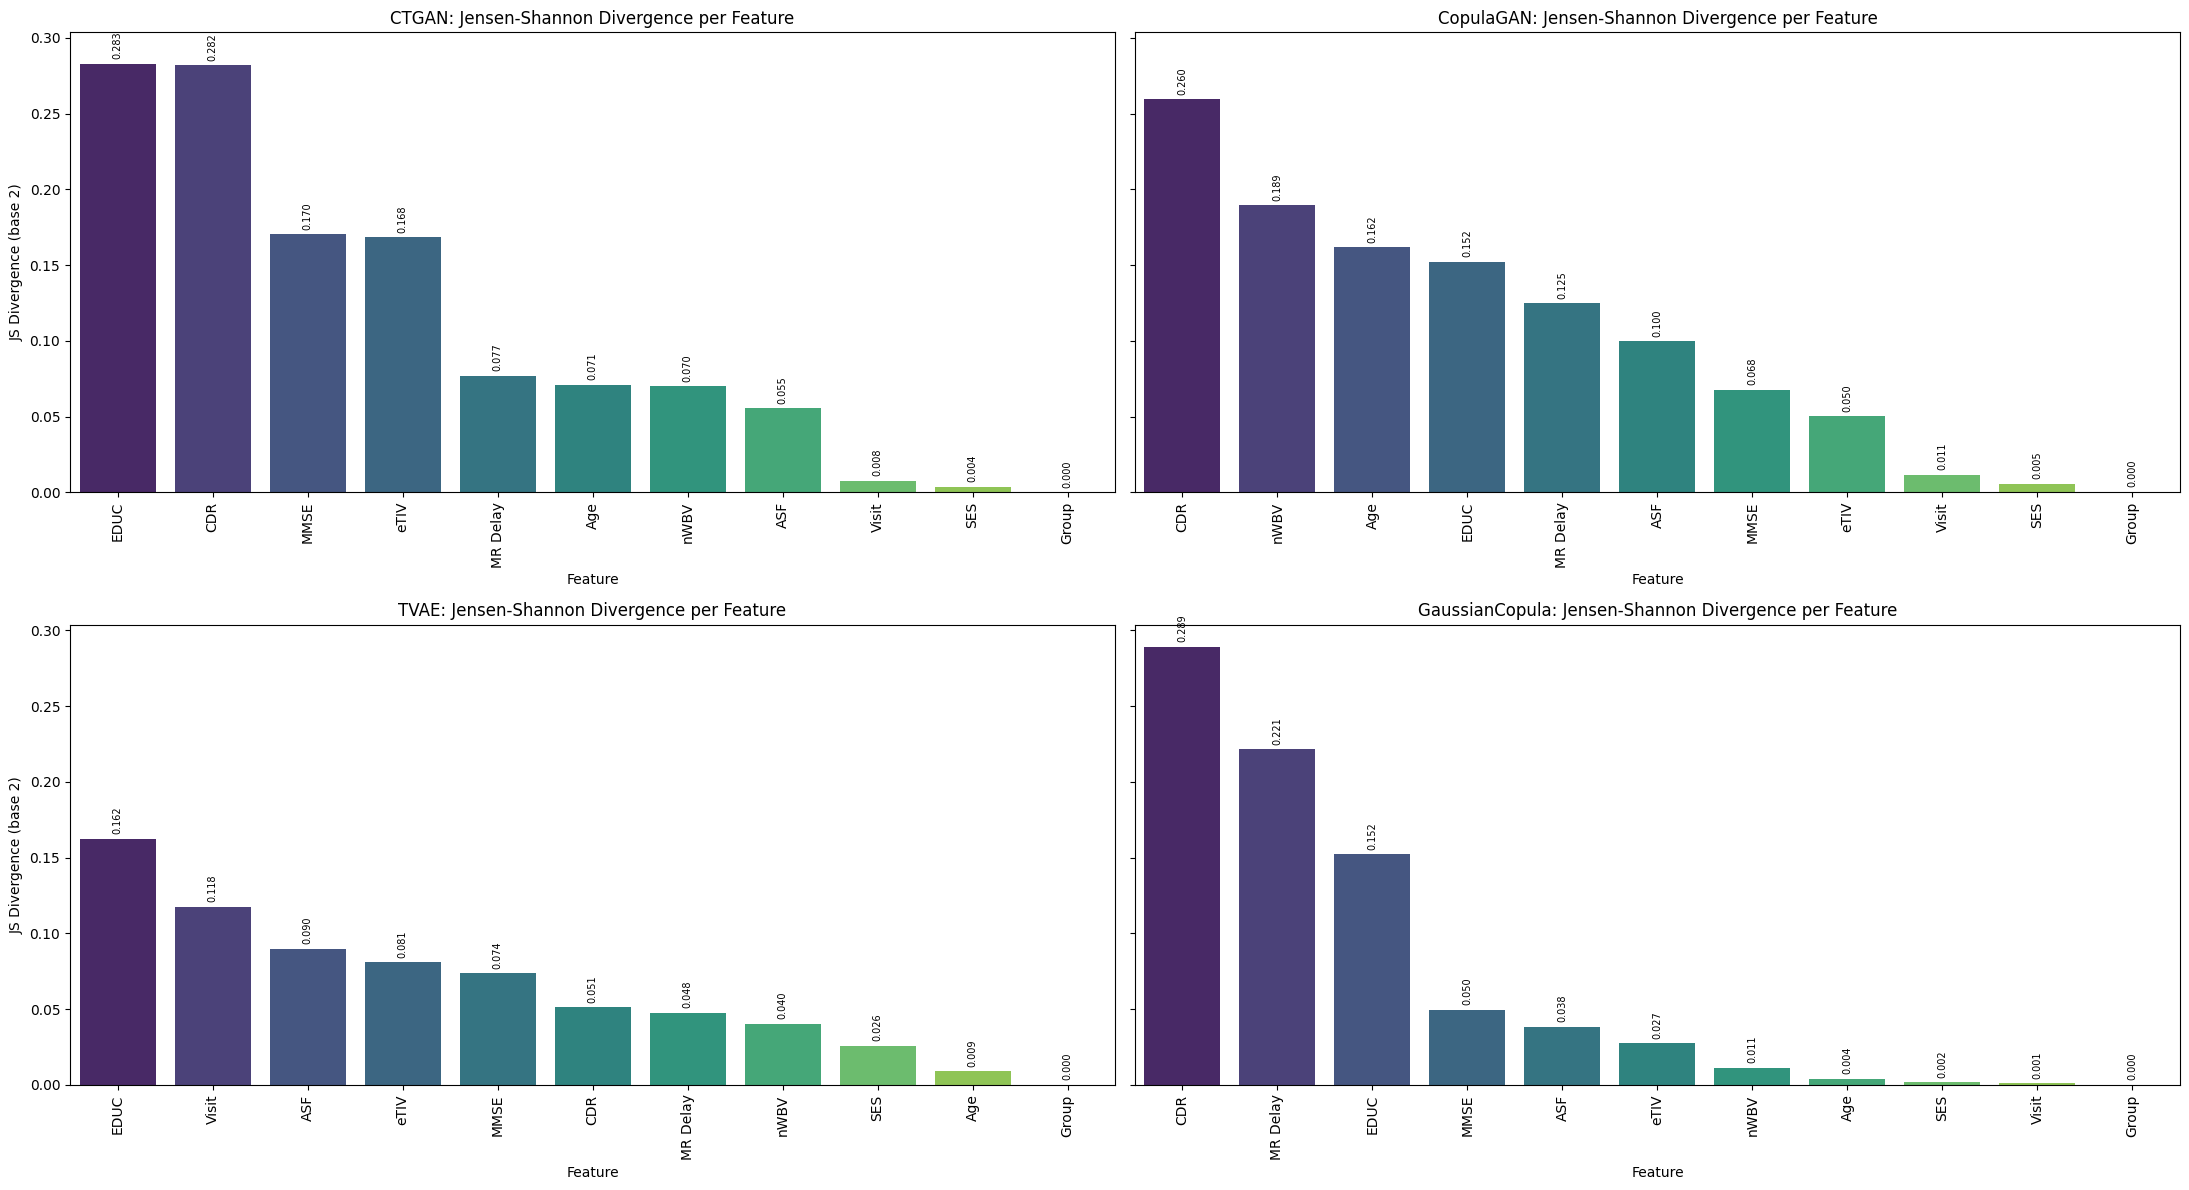

,Feature,JS_Divergence,Model
0,EDUC,0.282869,CTGAN
1,CDR,0.281926,CTGAN
2,MMSE,0.170275,CTGAN
3,eTIV,0.168448,CTGAN
4,MR Delay,0.076723,CTGAN
5,Age,0.070887,CTGAN
6,nWBV,0.069964,CTGAN
7,ASF,0.055499,CTGAN
8,Visit,0.007519,CTGAN
9,SES,0.003728,CTGAN


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

for model_name in model_order:
    js_df = compute_js_divergence(
        real_data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

#### 1.3 Wasserstein Distance

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

real_data = ad_data.copy()
numeric_cols = real_data.select_dtypes(include=[np.number]).columns
wasserstein_results = {}

for model_name, synth_df in synthetic_datasets.items():
    common_numeric_cols = [c for c in numeric_cols if c in synth_df.columns]
    scaler = StandardScaler().fit(real_data[common_numeric_cols])

    real_scaled = pd.DataFrame(
        scaler.transform(real_data[common_numeric_cols]),
        columns=common_numeric_cols
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synth_df[common_numeric_cols]),
        columns=common_numeric_cols
    )

    wasserstein_scores = []
    for col in common_numeric_cols:
        r = real_scaled[col].dropna().astype(float)
        s = synth_scaled[col].dropna().astype(float)

        try:
            w_dist = wasserstein_distance(r, s)
        except Exception:
            w_dist = np.nan

        wasserstein_scores.append({"Column": col, "Wasserstein": w_dist})

    results_df = pd.DataFrame(wasserstein_scores).sort_values("Wasserstein")
    wasserstein_results[model_name] = results_df

    print(f"\nWasserstein distances for {model_name}:")
    print(results_df)


Wasserstein distances for CTGAN:
      Column  Wasserstein
0      Group     0.011403
5        SES     0.047368
1      Visit     0.139263
2   MR Delay     0.144332
10       ASF     0.268387
7        CDR     0.298787
9       nWBV     0.351873
6       MMSE     0.373473
3        Age     0.609506
4       EDUC     0.782777
8       eTIV     0.828579

Wasserstein distances for CopulaGAN:
      Column  Wasserstein
0      Group     0.033448
5        SES     0.077392
8       eTIV     0.199853
6       MMSE     0.203323
1      Visit     0.248275
4       EDUC     0.279912
7        CDR     0.389764
10       ASF     0.597786
2   MR Delay     0.908244
3        Age     0.927990
9       nWBV     1.024700

Wasserstein distances for TVAE:
      Column  Wasserstein
0      Group     0.027435
3        Age     0.132289
5        SES     0.224170
8       eTIV     0.291329
7        CDR     0.295708
10       ASF     0.326488
9       nWBV     0.343686
6       MMSE     0.359355
2   MR Delay     0.370786
1      Visi


CTGAN - Wasserstein Distance:
Group: 0.0057
Visit: 0.0328
MR Delay: 0.0355
Age: 0.1273
EDUC: 0.1430
SES: 0.0131
MMSE: 0.0539
CDR: 0.0565
eTIV: 0.1618
nWBV: 0.0740
ASF: 0.0517

CopulaGAN - Wasserstein Distance:
Group: 0.0167
Visit: 0.0585
MR Delay: 0.2234
Age: 0.1939
EDUC: 0.0511
SES: 0.0214
MMSE: 0.0294
CDR: 0.0737
eTIV: 0.0390
nWBV: 0.2156
ASF: 0.1151

TVAE - Wasserstein Distance:
Group: 0.0137
Visit: 0.1117
MR Delay: 0.0912
Age: 0.0276
EDUC: 0.0977
SES: 0.0621
MMSE: 0.0519
CDR: 0.0559
eTIV: 0.0569
nWBV: 0.0723
ASF: 0.0629

GaussianCopula - Wasserstein Distance:
Group: 0.0063
Visit: 0.0133
MR Delay: 0.1602
Age: 0.0094
EDUC: 0.0309
SES: 0.0228
MMSE: 0.0405
CDR: 0.0932
eTIV: 0.0178
nWBV: 0.0155
ASF: 0.0175

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.038847,0.017753,0.160207
1,TVAE,0.063999,0.062123,0.111732
2,CTGAN,0.068679,0.053942,0.161801
3,CopulaGAN,0.094352,0.058518,0.223401


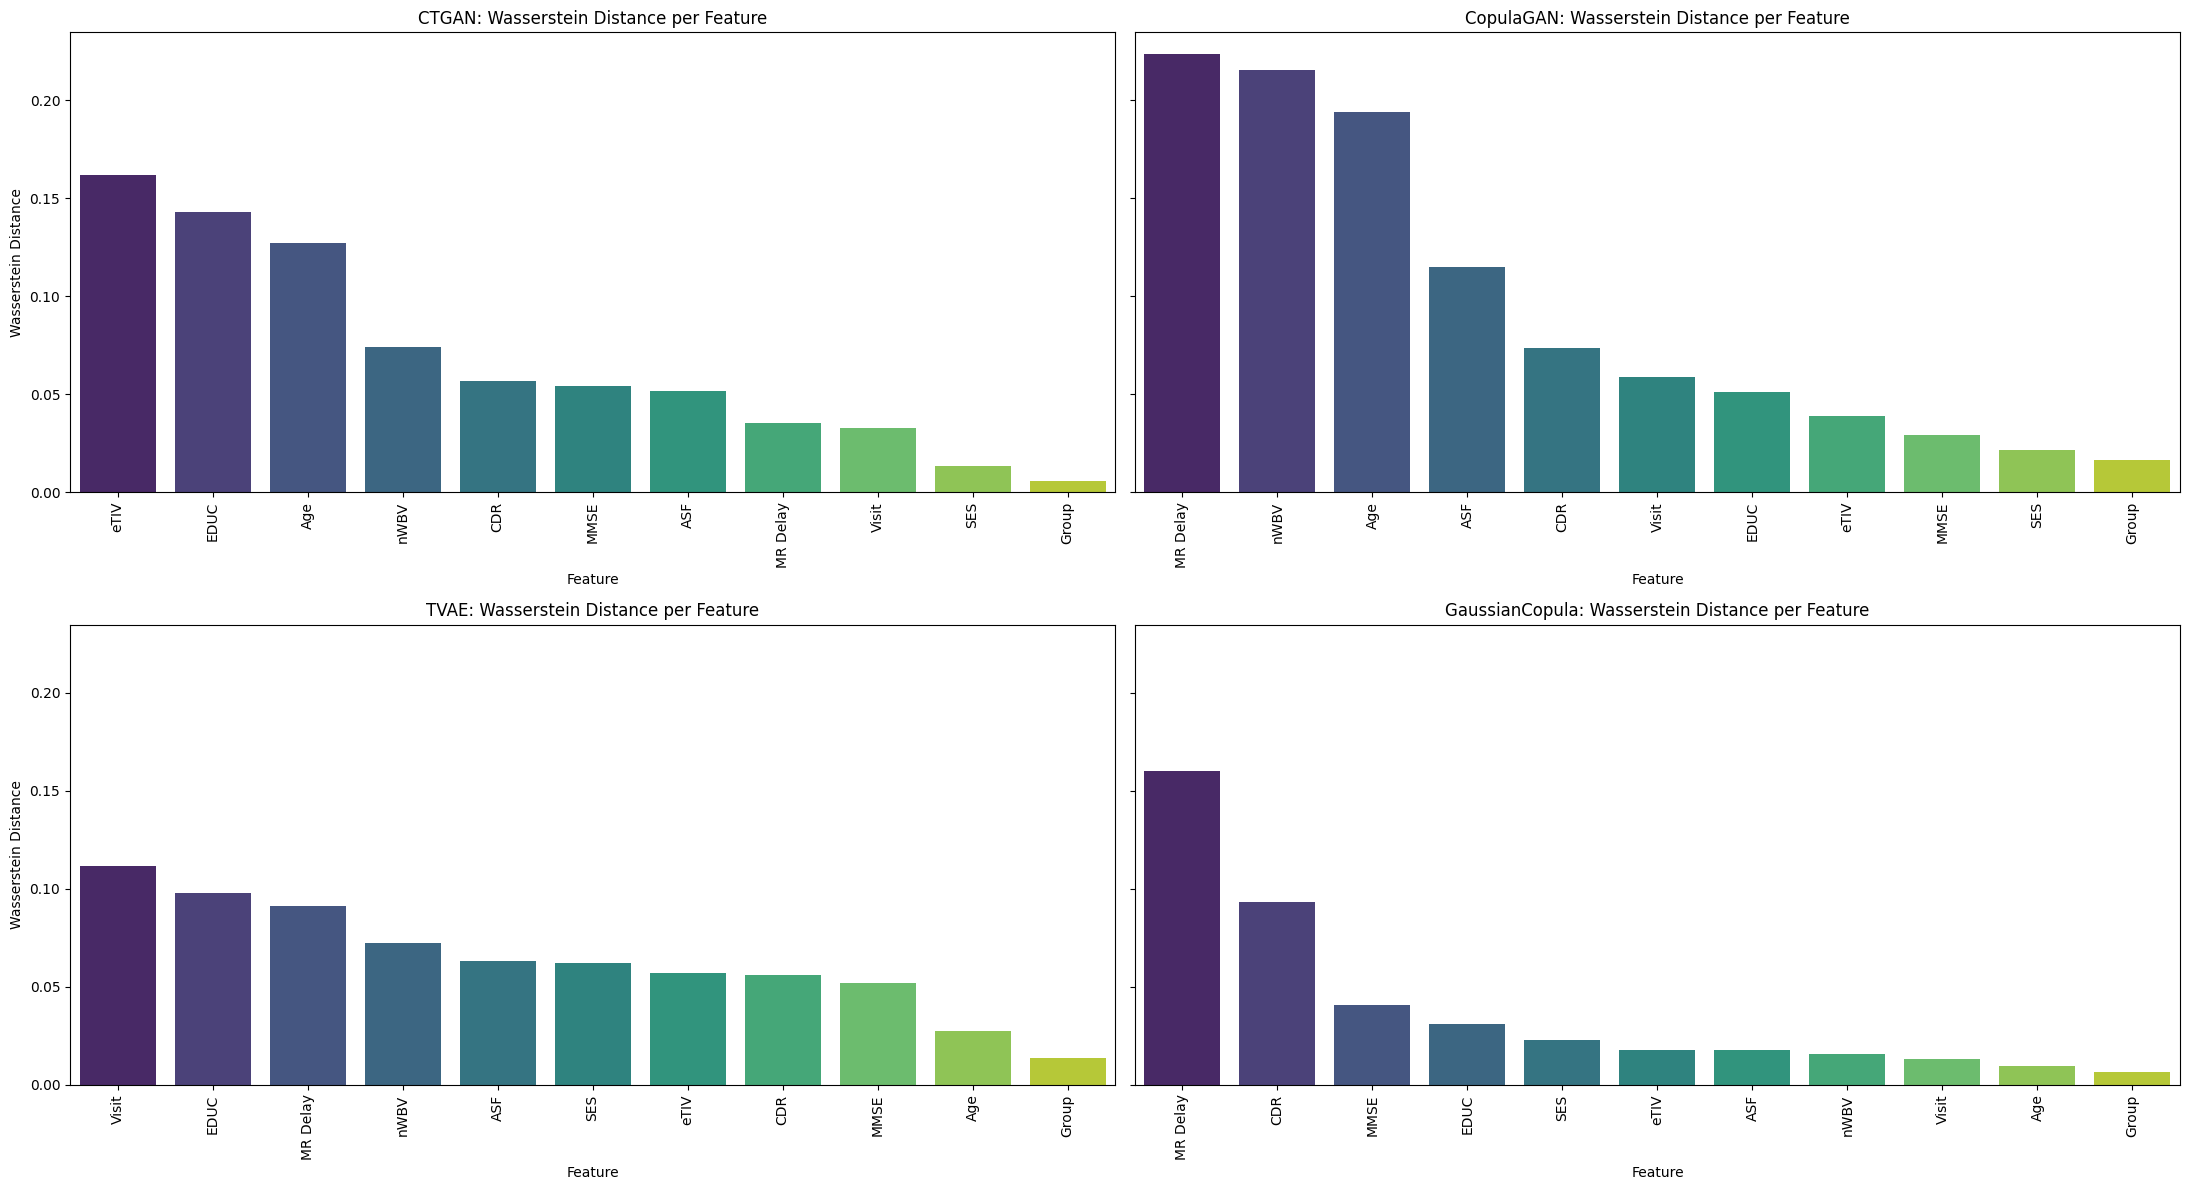

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in common_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

#### 1.4 Gower Distance 

In [8]:
import numpy as np
import pandas as pd
import gower

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

X_real = real_data.drop(columns=[target_col], errors="ignore")
gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9841, Avg = 0.7750

Intra-set Similarity (Synthetic):
Max = 0.9675, Avg = 0.7413

Cross-set Similarity (Real vs Synthetic):
Max = 0.9718, Avg = 0.7477

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9841, Avg = 0.7750

Intra-set Similarity (Synthetic):
Max = 0.9835, Avg = 0.7233

Cross-set Similarity (Real vs Synthetic):
Max = 0.9732, Avg = 0.7270

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9841, Avg = 0.7750

Intra-set Similarity (Synthetic):
Max = 0.9950, Avg = 0.7885

Cross-set Similarity (Real vs Synthetic):
Max = 0.9908, Avg = 0.7979

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9841, Avg = 0.7750

Intra-set Similarity (Synthetic):
Max = 0.9926, Avg = 0.8013

Cross-set Similarity (Real vs Synthetic):
Max = 0.9861, Avg = 0.7838


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.984067,0.774983,0.967548,0.741345,0.971845,0.747682
1,CopulaGAN,0.984067,0.774983,0.983545,0.723303,0.973178,0.727022
2,TVAE,0.984067,0.774983,0.995000,0.788543,0.990824,0.797855
3,GaussianCopula,0.984067,0.774983,0.992649,0.801298,0.986098,0.783766


#### 1.5. t-SNE Visualization

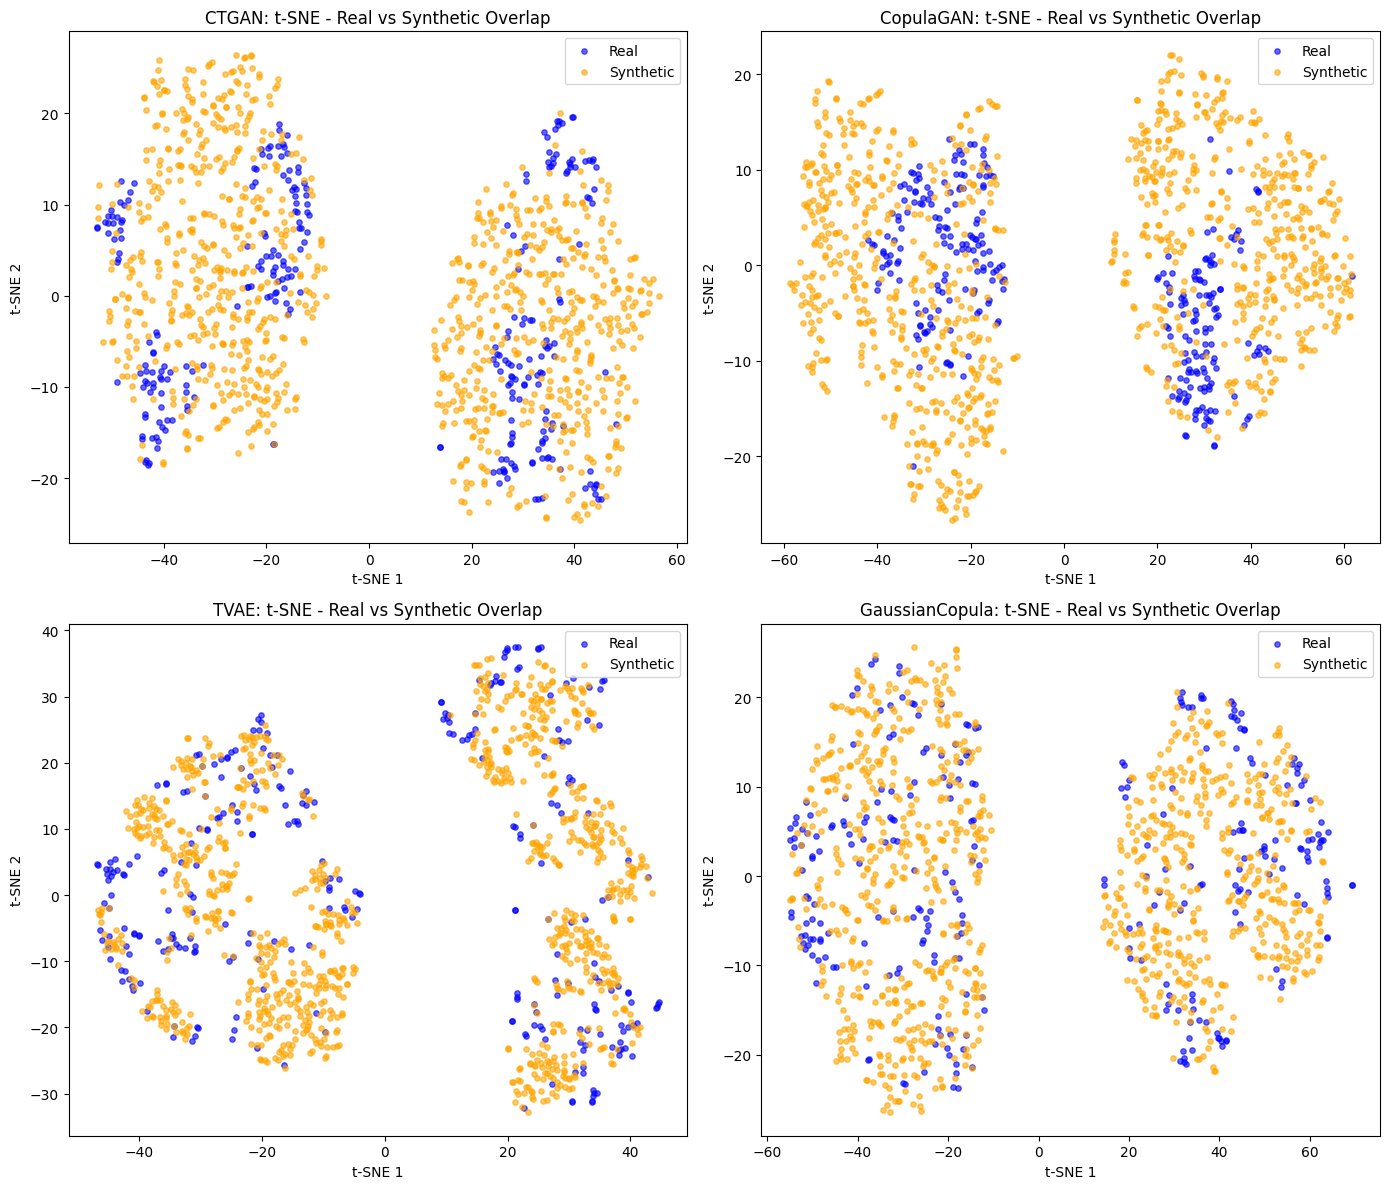

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    combined = np.vstack([real_scaled[common_cols].values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

#### 1.6 MMD (Maximum Mean Discrepancy)

In [10]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = real_data.drop(columns=[target_col], errors="ignore")
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.0812
CopulaGAN - MMD score: 0.1229
TVAE - MMD score: 0.0643
GaussianCopula - MMD score: 0.0358

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.035760
1,TVAE,0.064294
2,CTGAN,0.081172
3,CopulaGAN,0.122851


### 1.7 Cosine Similarity

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = real_data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: -0.0013
Maximum cosine similarity: 0.9639

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0030
Maximum cosine similarity: 0.9675

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0215
Maximum cosine similarity: 0.9958

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0144
Maximum cosine similarity: 0.9917

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.021514,0.995779
1,GaussianCopula,0.014374,0.991668
2,CTGAN,-0.001284,0.963863
3,CopulaGAN,-0.003031,0.967523


#### 1.8 Nearest Neighbours

In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = ad_data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.5921
Minimum NN Distance (Synthetic -> Real): 0.7459
5th Percentile NN Distance: 1.5711

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.9135
Minimum NN Distance (Synthetic -> Real): 0.8591
5th Percentile NN Distance: 1.6432

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.2963
Minimum NN Distance (Synthetic -> Real): 0.2148
5th Percentile NN Distance: 0.7021

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.6061
Minimum NN Distance (Synthetic -> Real): 0.4108
5th Percentile NN Distance: 0.8667

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CopulaGAN,2.913521,0.859061,1.643171
1,CTGAN,2.592114,0.745864,1.571075
2,GaussianCopula,1.606060,0.410845,0.866685
3,TVAE,1.296308,0.214838,0.702066


# Stats 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,8.955902,6.302499,12.746864
1,CopulaGAN,15.111649,5.685795,24.373376
2,TVAE,13.633247,7.033570,26.976968
3,GaussianCopula,15.050539,1.492183,14.123387


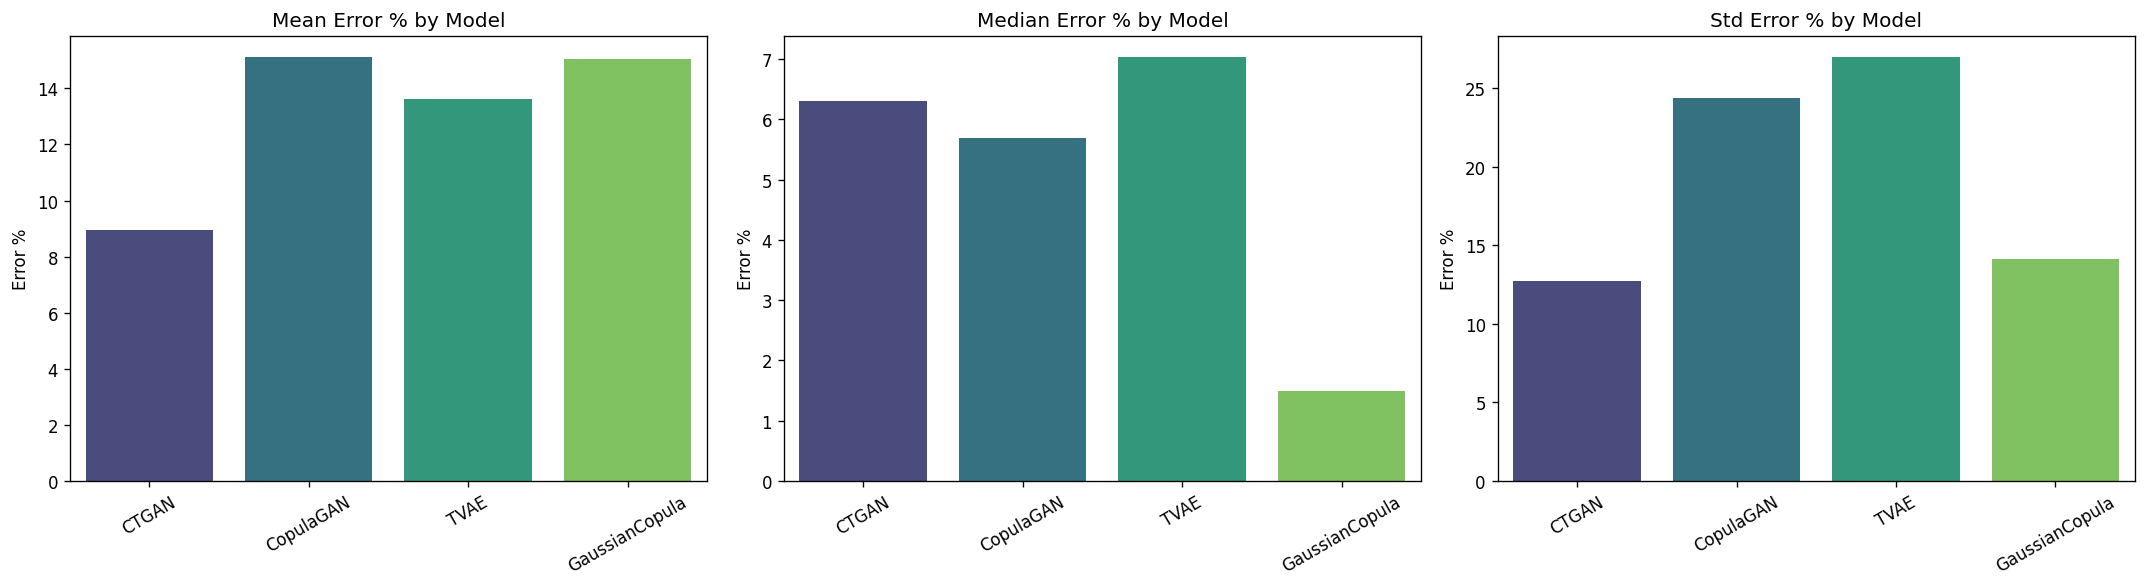

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "Group" in num_cols:
    num_cols.remove("Group")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


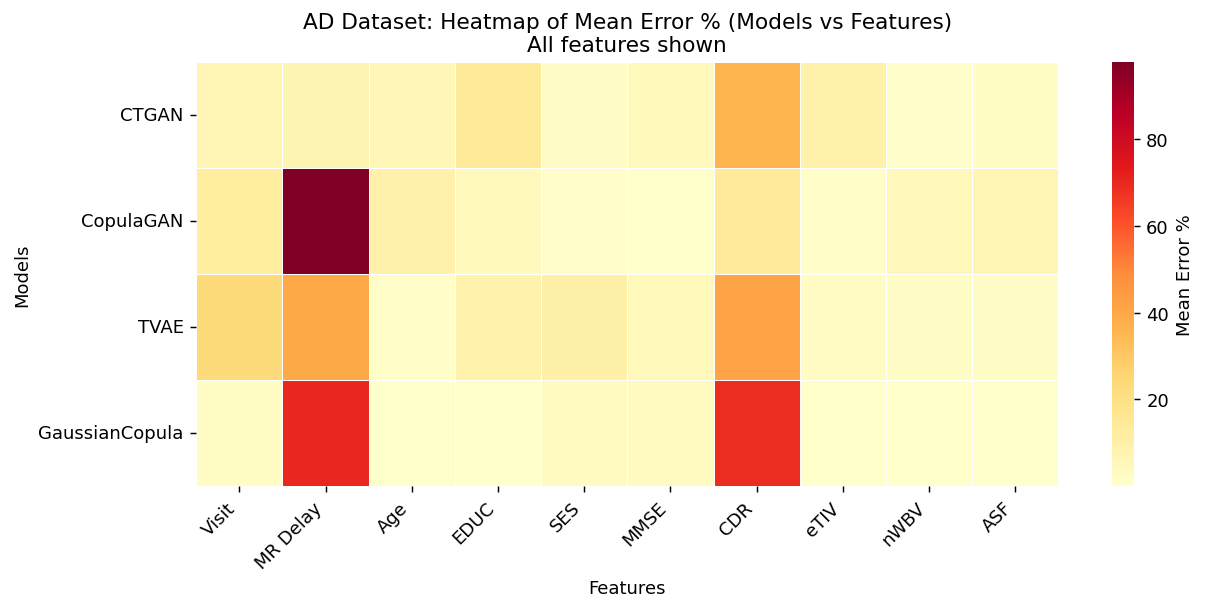

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"AD Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

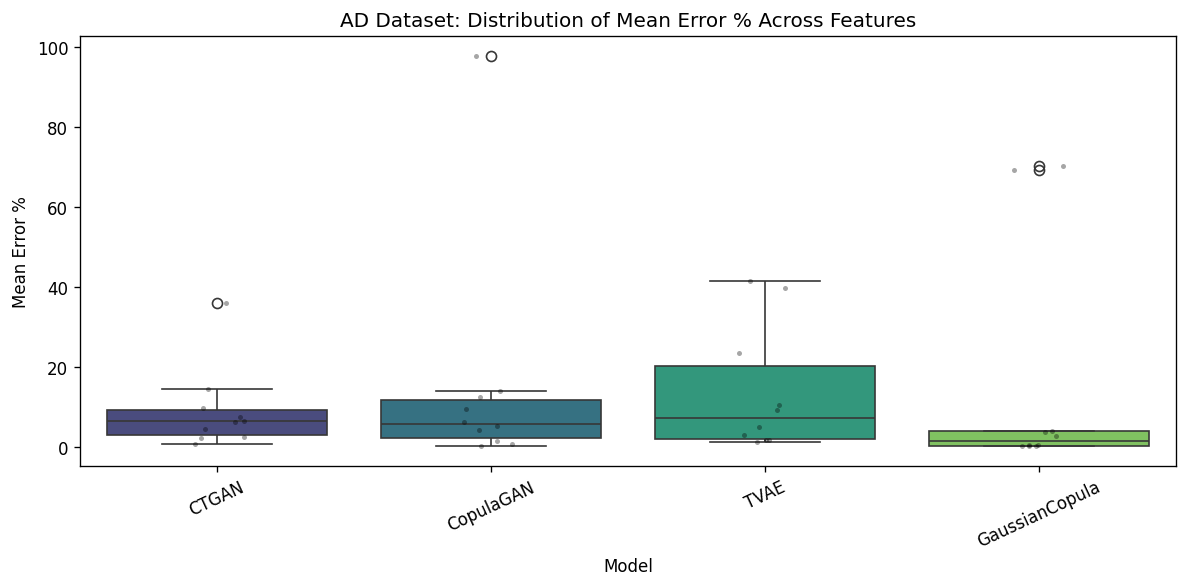

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("AD Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

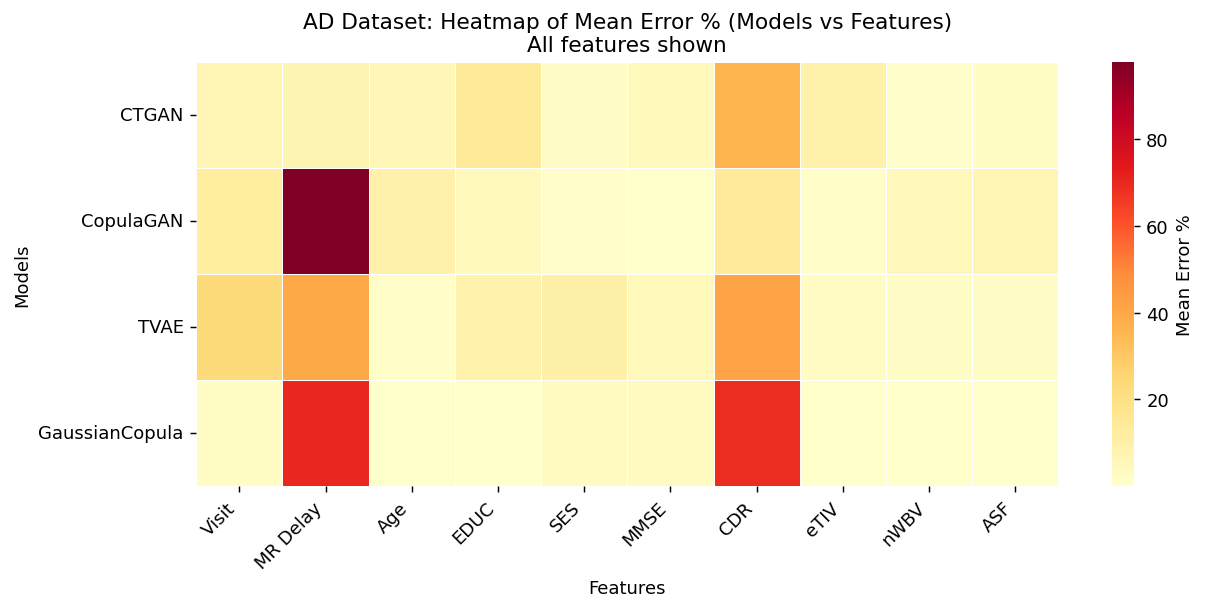

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"AD Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis

In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_ad(real_df, synth_df, target="Group"):
    num_cols = [c for c in real_df.columns if c != target]

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)

    return corr_df, target_df

In [18]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = ad_data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    corr_results, target_results = bivariate_quality_ad(
        real_df=real_df,
        synth_df=synth_df,
        target="Group"
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by Group class:")
    display(target_results.head(10))
    print("=" * 60)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results["delta_corr"].iloc[0] if not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results["delta_corr"].head(10).mean() if not corr_results.empty else None,
        "TopTargetDiff": target_results["delta_wasserstein"].iloc[0] if not target_results.empty else None,
        "MeanTop10TargetDiff": target_results["delta_wasserstein"].head(10).mean() if not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
43,eTIV,ASF,0.972707
0,Visit,MR Delay,0.905110
24,EDUC,SES,0.709793
35,MMSE,CDR,0.682467
22,Age,nWBV,0.552849
40,CDR,nWBV,0.418437
37,MMSE,nWBV,0.360704
29,EDUC,ASF,0.349848
27,EDUC,eTIV,0.318571
44,nWBV,ASF,0.285473


CTGAN - Features that differ most by Group class:


,feature,delta_wasserstein
6,CDR,0.271777
5,MMSE,0.124701
8,nWBV,0.108127
3,EDUC,0.027080
7,eTIV,0.018399
4,SES,0.016848
1,MR Delay,0.016820
0,Visit,0.016811
2,Age,0.010426
9,ASF,0.002857



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
24,EDUC,SES,0.694768
35,MMSE,CDR,0.343613
0,Visit,MR Delay,0.283324
32,SES,eTIV,0.249674
34,SES,ASF,0.246910
19,Age,MMSE,0.184922
33,SES,nWBV,0.117784
40,CDR,nWBV,0.108421
30,SES,MMSE,0.105061
37,MMSE,nWBV,0.104157


GaussianCopula - Features that differ most by Group class:


,feature,delta_wasserstein
6,CDR,0.212336
5,MMSE,0.112406
8,nWBV,0.088128
4,SES,0.052113
1,MR Delay,0.035640
0,Visit,0.019573
3,EDUC,0.015069
2,Age,0.014831
7,eTIV,0.007878
9,ASF,0.000976


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.972707,0.555596,0.271777,0.061385
1,CopulaGAN,0.992301,0.560648,0.249273,0.065217
2,TVAE,0.480433,0.283092,0.120677,0.045514
3,GaussianCopula,0.694768,0.243863,0.212336,0.055895


# 3 Multivariate Analysis

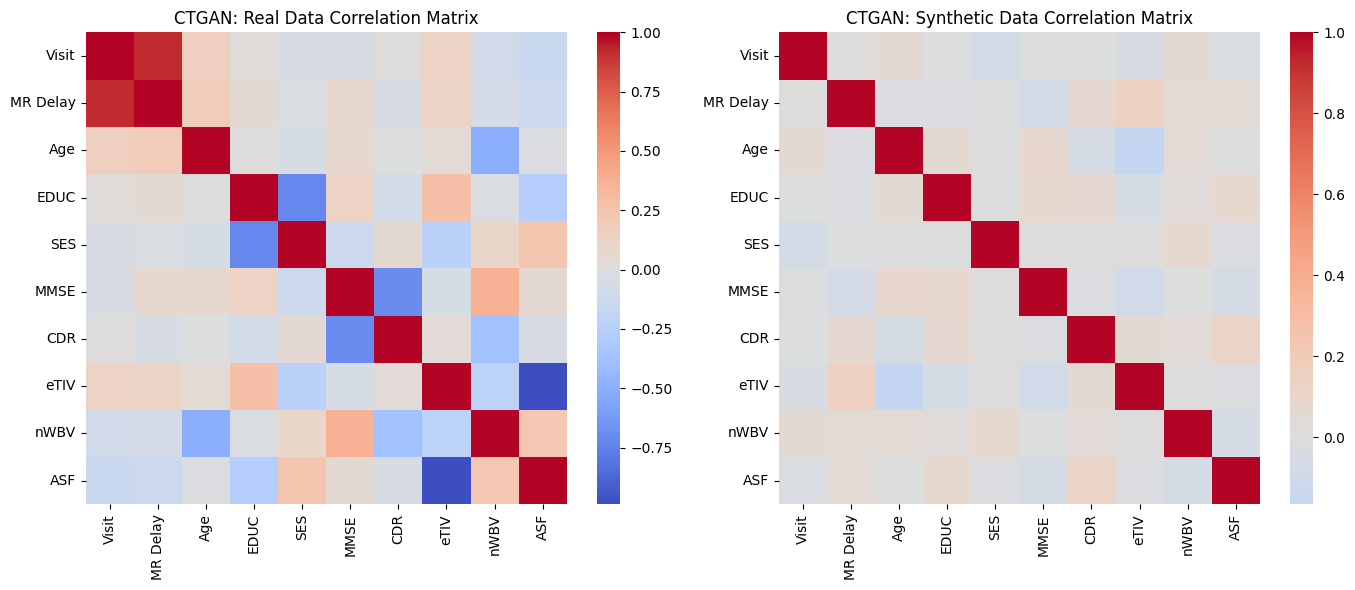

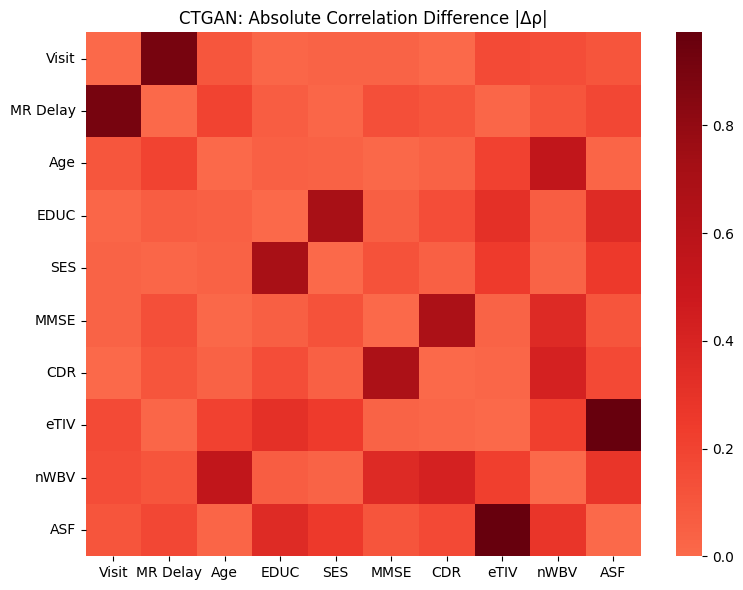

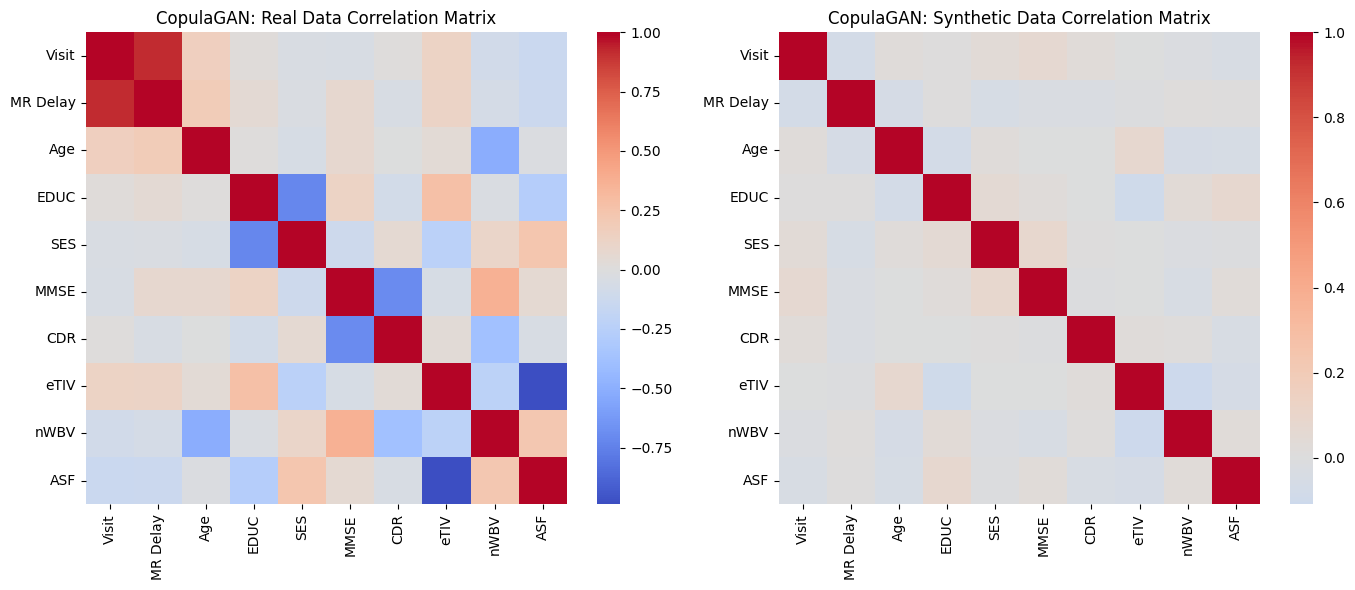

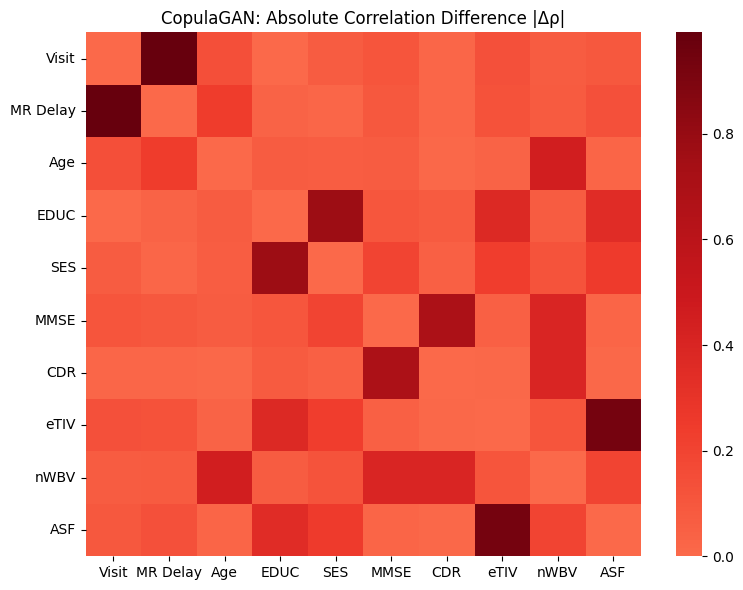

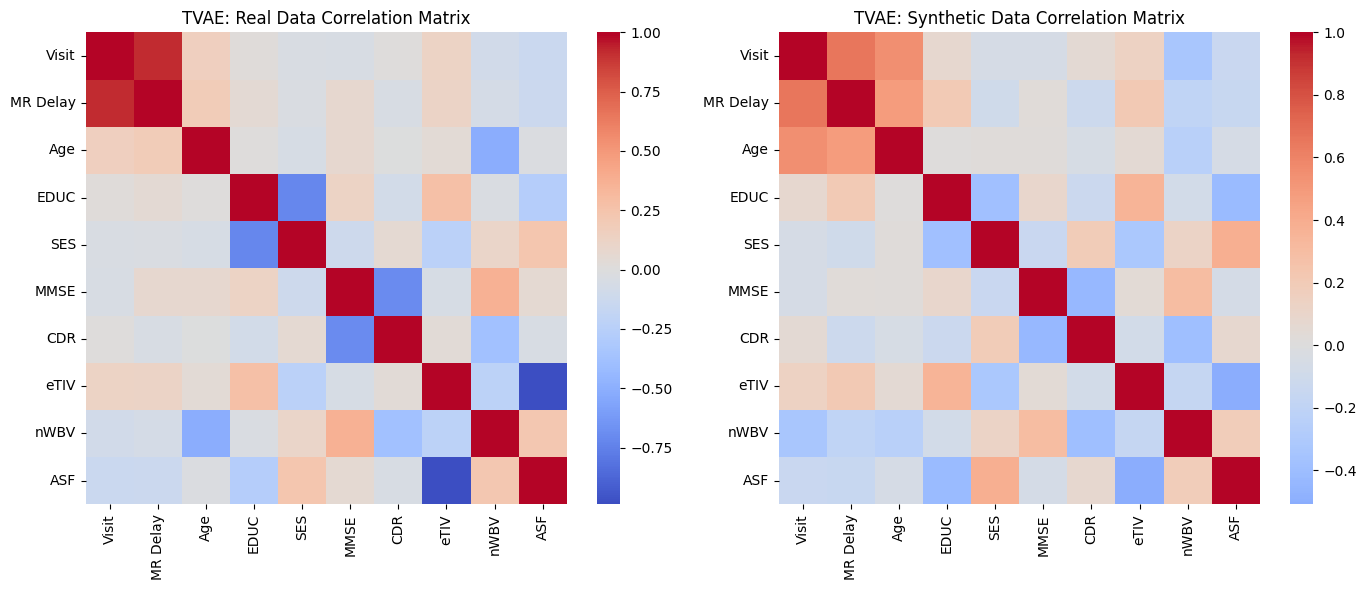

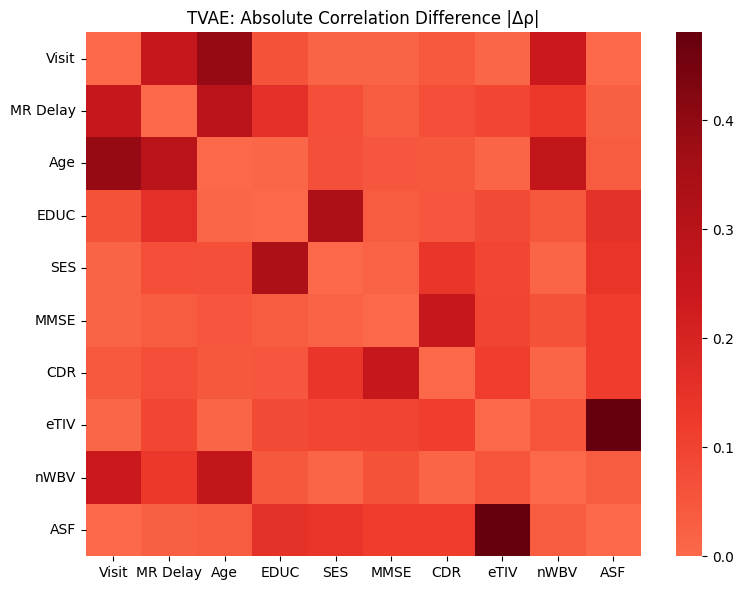

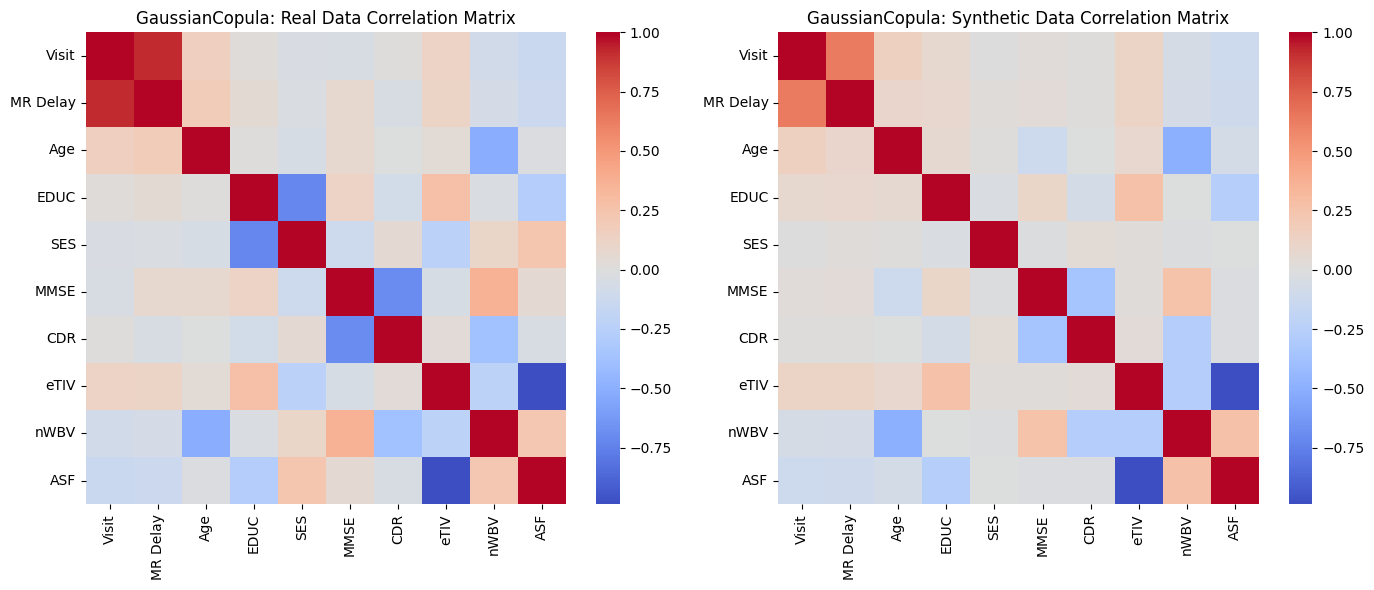

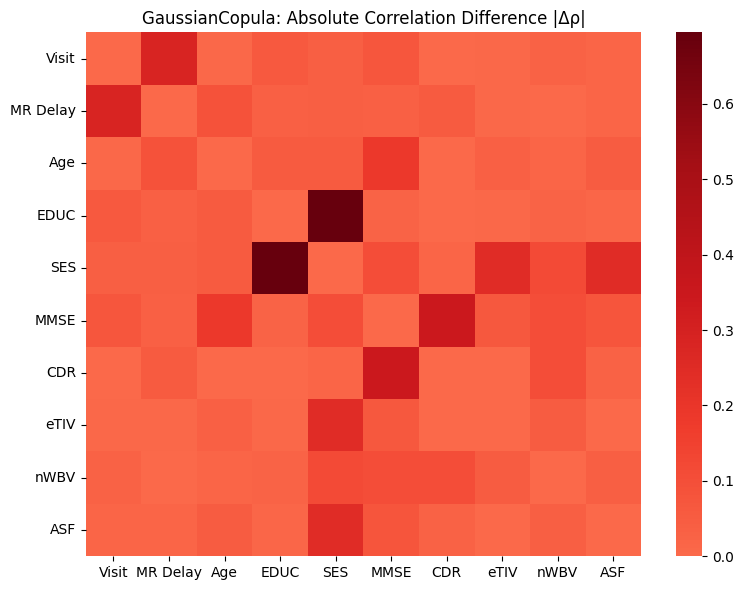

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = ad_data.copy()
num_cols = [c for c in real_df.columns if c != "Group"]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.054562


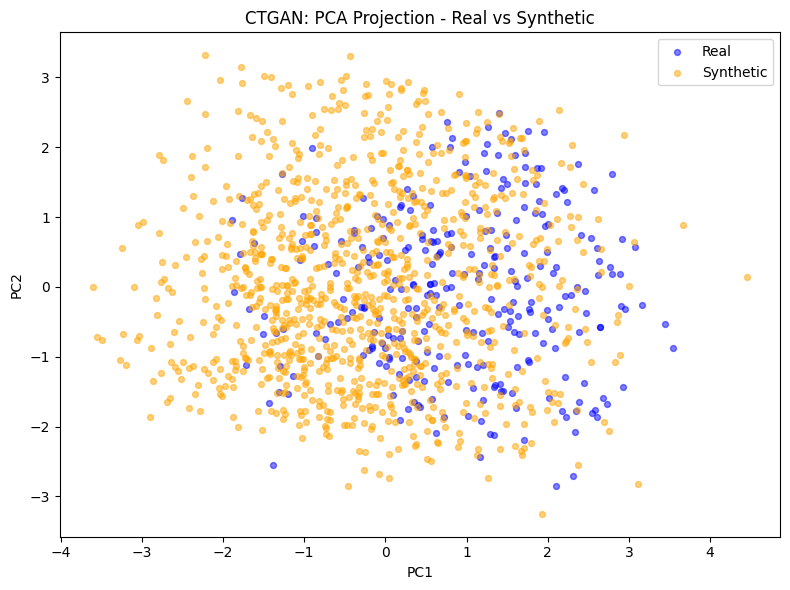

CTGAN - Two-Sample Classifier Accuracy: 0.9326

CopulaGAN - Global MMD (RBF): 0.078057


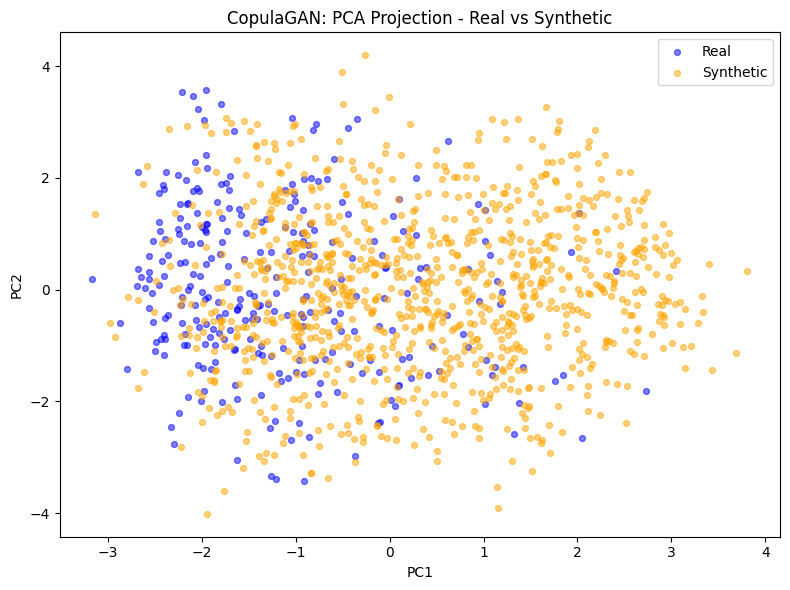

CopulaGAN - Two-Sample Classifier Accuracy: 0.9534

TVAE - Global MMD (RBF): 0.057569


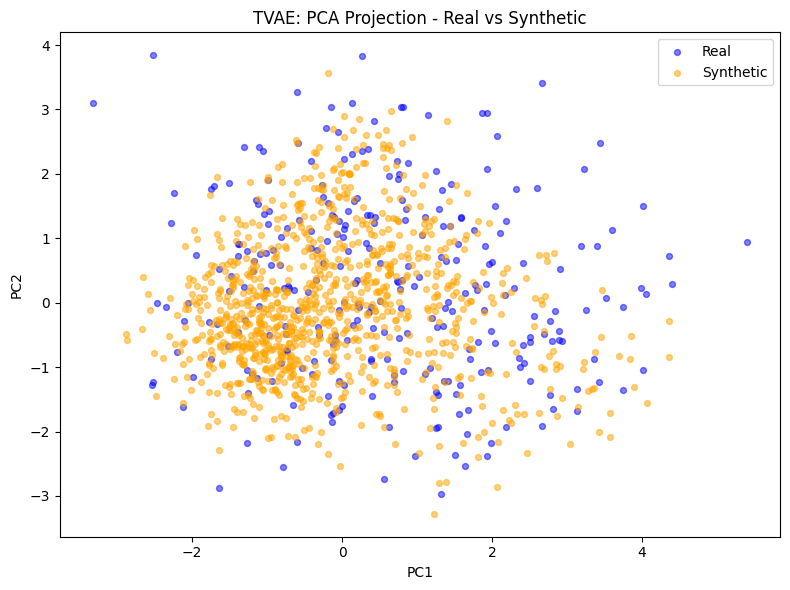

TVAE - Two-Sample Classifier Accuracy: 0.9041

GaussianCopula - Global MMD (RBF): 0.028136


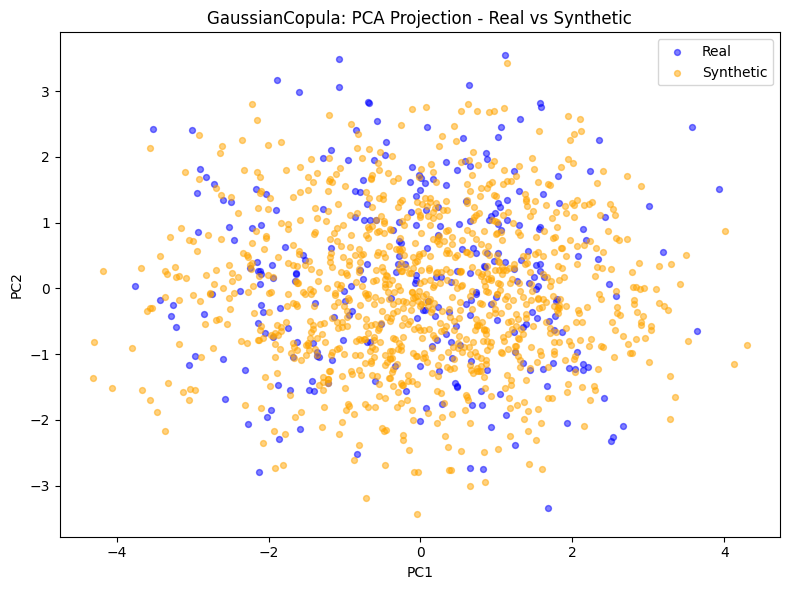

GaussianCopula - Two-Sample Classifier Accuracy: 0.9145

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.028136,0.914508
1,CTGAN,0.054562,0.932642
2,TVAE,0.057569,0.904145
3,CopulaGAN,0.078057,0.953368


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

X_real_df = ad_data.drop(columns=[target_col], errors="ignore")
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = X_synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers

In [21]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def evaluate_models(train_df, test_df, label_col="Group", models=models, test_size=0.2, seed=42, resplit=False):
    """Use participant-level train/test frames as-is by default (resplit=False)."""
    X_train = train_df.drop(columns=[label_col]).copy()
    y_train = train_df[label_col].copy()
    X_test = test_df.drop(columns=[label_col]).copy()
    y_test = test_df[label_col].copy()

    train_keep = ~X_train.isna().any(axis=1)
    test_keep = ~X_test.isna().any(axis=1)
    X_train, y_train = X_train.loc[train_keep], y_train.loc[train_keep]
    X_test, y_test = X_test.loc[test_keep], y_test.loc[test_keep]

    if resplit:
        X_train, _, y_train, _ = train_test_split(
            X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
        )
        _, X_test, _, y_test = train_test_split(
            X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
        )


    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)


In [22]:
import pandas as pd

label_col = "Group"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=train_real,
    test_df=test_real,
    label_col="Group",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=test_real,
        label_col="Group",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]
    if "Precision_TRTR" in comparison.columns and "Precision_TSTR" in comparison.columns:
        comparison["Precision_Drop"] = comparison["Precision_TRTR"] - comparison["Precision_TSTR"]
    if "Recall_TRTR" in comparison.columns and "Recall_TSTR" in comparison.columns:
        comparison["Recall_Drop"] = comparison["Recall_TRTR"] - comparison["Recall_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

_drop_cols = [
    c for c in [
        "Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop", "AUC_Drop"
    ]
    if c in combined_comparison.columns
]
summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[_drop_cols]
    .mean()
    .sort_values("Accuracy_Drop" if "Accuracy_Drop" in _drop_cols else _drop_cols[0])
)

print("Average utility drops by synthetic generator (lower is better):")
display(summary)

# Persist Accuracy / Precision / Recall / F1 utility gaps
from pathlib import Path as _Path
_out_dir = _Path.cwd() / "utility_four_metrics"
_out_dir.mkdir(parents=True, exist_ok=True)
_ds_tag = "Alzheimer"
_xlsx = _out_dir / f"TRTR_TSTR_four_metrics_{_ds_tag}.xlsx"
_drop_export = [c for c in ["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop", "AUC_Drop"] if c in combined_comparison.columns]
_summary_export = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)[_drop_export].mean()
    .sort_values("Accuracy_Drop" if "Accuracy_Drop" in _drop_export else _drop_export[0])
)
with pd.ExcelWriter(_xlsx, engine="openpyxl") as _w:
    combined_comparison.to_excel(_w, sheet_name="All_Comparisons", index=False)
    _summary_export.to_excel(_w, sheet_name="Summary", index=False)
    for _g, _gdf in combined_comparison.groupby("Synthetic_Model"):
        _safe = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(_g))[:31]
        _gdf.to_excel(_w, sheet_name=_safe or "model", index=False)
print(f"Wrote four-metric utility results → {_xlsx.resolve()}")
print(_summary_export.to_string(index=False))


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.985714,0.984127,0.999173
6,ExtraTrees,0.957143,0.953846,0.999173
9,MLP,0.928571,0.923077,0.994210
1,SVM-RBF,0.985714,0.984127,0.993383
5,RandomForest,0.985714,0.984127,0.992969
8,AdaBoost,0.957143,0.953846,0.990902
3,NaiveBayes,0.971429,0.968750,0.987179
7,GradientBoost,0.971429,0.968750,0.985112
2,KNN,0.914286,0.892857,0.947064
4,DecisionTree,0.928571,0.925373,0.935897


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.700000,0.676923,0.714640
0,LogReg,0.685714,0.633333,0.713813
1,SVM-RBF,0.728571,0.627451,0.696443
8,AdaBoost,0.657143,0.555556,0.659222
7,GradientBoost,0.557143,0.456140,0.549214
4,DecisionTree,0.514286,0.540541,0.527709
5,RandomForest,0.485714,0.357143,0.521092
2,KNN,0.514286,0.451613,0.517370
6,ExtraTrees,0.500000,0.406780,0.483871
9,MLP,0.428571,0.259259,0.289495


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
8,AdaBoost,0.971429,0.968750,1.000000
0,LogReg,0.971429,0.968750,0.999173
3,NaiveBayes,0.985714,0.984127,0.997519
6,ExtraTrees,0.900000,0.898551,0.990902
5,RandomForest,0.914286,0.911765,0.990902
1,SVM-RBF,0.914286,0.909091,0.981803
7,GradientBoost,0.885714,0.882353,0.975186
2,KNN,0.785714,0.788732,0.915219
9,MLP,0.800000,0.781250,0.864351
4,DecisionTree,0.657143,0.600000,0.649297


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
9,DecisionTree,0.928571,0.925373,0.935897,0.657143,0.600000,0.649297,0.286600,0.325373,0.271429,GaussianCopula
2,MLP,0.928571,0.923077,0.994210,0.800000,0.781250,0.864351,0.129859,0.141827,0.128571,GaussianCopula
8,KNN,0.914286,0.892857,0.947064,0.785714,0.788732,0.915219,0.031844,0.104125,0.128571,GaussianCopula
3,SVM-RBF,0.985714,0.984127,0.993383,0.914286,0.909091,0.981803,0.011580,0.075036,0.071429,GaussianCopula
7,GradientBoost,0.971429,0.968750,0.985112,0.885714,0.882353,0.975186,0.009926,0.086397,0.085714,GaussianCopula
1,ExtraTrees,0.957143,0.953846,0.999173,0.900000,0.898551,0.990902,0.008271,0.055295,0.057143,GaussianCopula
4,RandomForest,0.985714,0.984127,0.992969,0.914286,0.911765,0.990902,0.002068,0.072362,0.071429,GaussianCopula
0,LogReg,0.985714,0.984127,0.999173,0.971429,0.968750,0.999173,0.000000,0.015377,0.014286,GaussianCopula
5,AdaBoost,0.957143,0.953846,0.990902,0.971429,0.968750,1.000000,-0.009098,-0.014904,-0.014286,GaussianCopula
6,NaiveBayes,0.971429,0.968750,0.987179,0.985714,0.984127,0.997519,-0.010339,-0.015377,-0.014286,GaussianCopula


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
3,TVAE,0.019603
2,GaussianCopula,0.046071
1,CopulaGAN,0.307113
0,CTGAN,0.415219



CTGAN - TSTR


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.700000,0.676923,0.714640
0,LogReg,0.685714,0.633333,0.713813
1,SVM-RBF,0.728571,0.627451,0.696443
8,AdaBoost,0.657143,0.555556,0.659222
7,GradientBoost,0.557143,0.456140,0.549214
4,DecisionTree,0.514286,0.540541,0.527709
5,RandomForest,0.485714,0.357143,0.521092
2,KNN,0.514286,0.451613,0.517370
6,ExtraTrees,0.500000,0.406780,0.483871
9,MLP,0.428571,0.259259,0.289495


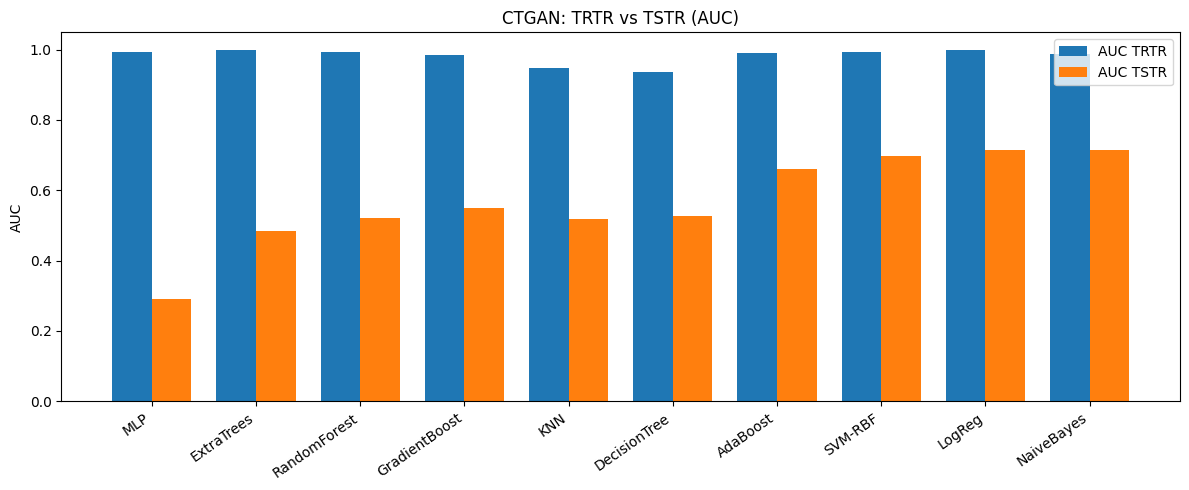

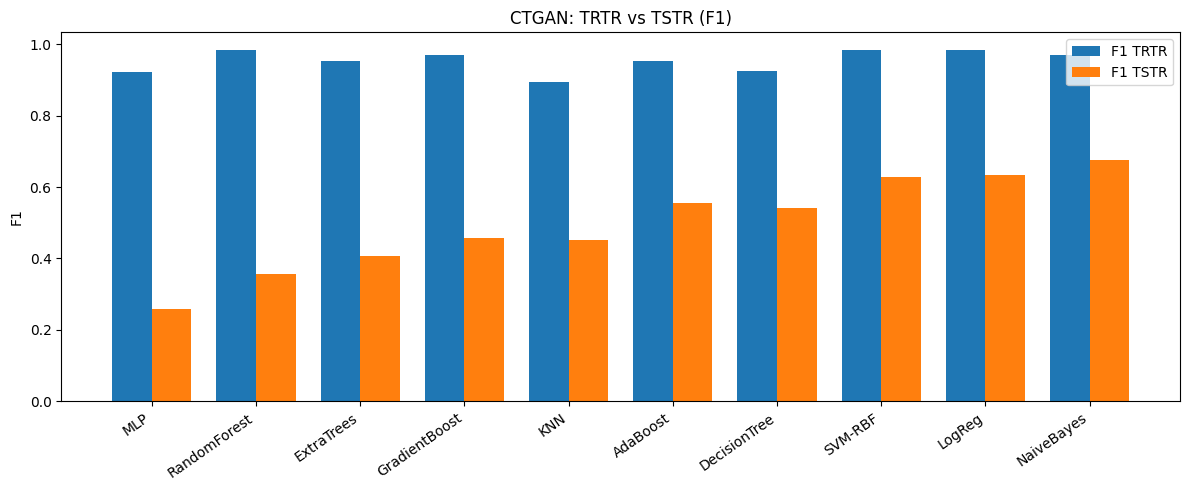

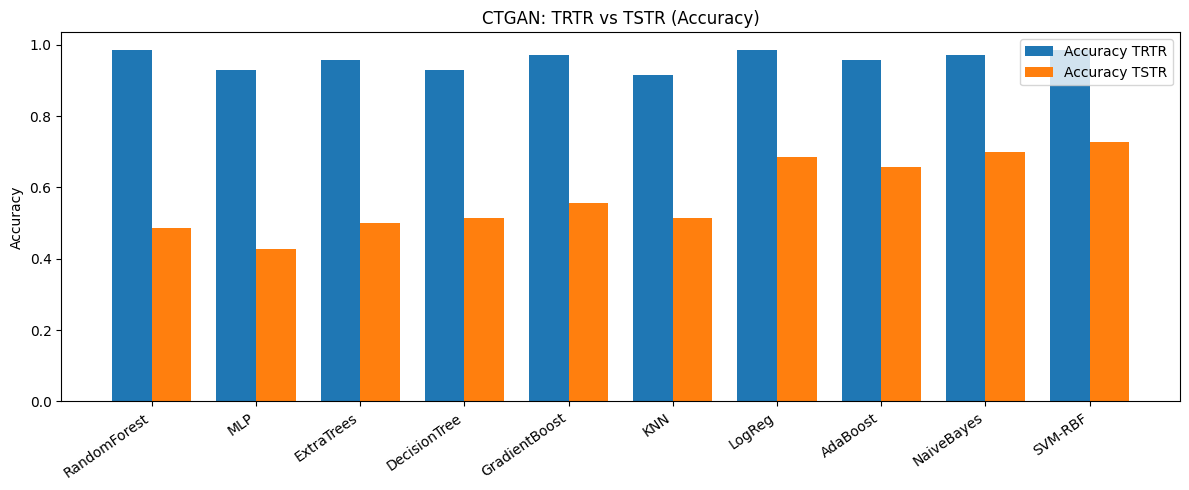

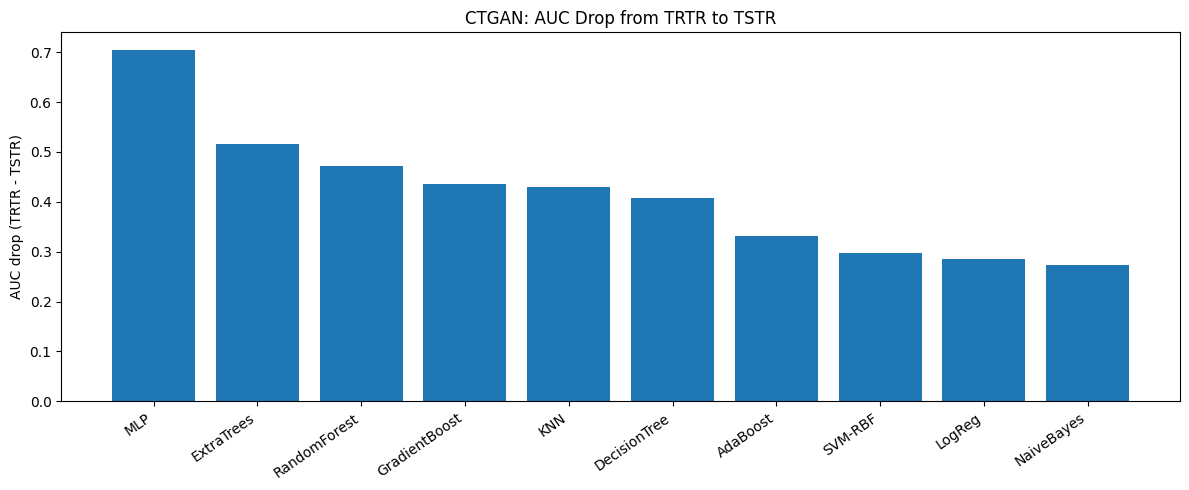


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
1,SVM-RBF,0.728571,0.641509,0.846981
3,NaiveBayes,0.714286,0.629630,0.839537
0,LogReg,0.657143,0.586207,0.775021
6,ExtraTrees,0.685714,0.620690,0.715881
8,AdaBoost,0.571429,0.571429,0.691894
7,GradientBoost,0.685714,0.607143,0.676592
5,RandomForest,0.628571,0.535714,0.644334
2,KNN,0.600000,0.500000,0.538875
4,DecisionTree,0.542857,0.448276,0.530190
9,MLP,0.500000,0.339623,0.494624


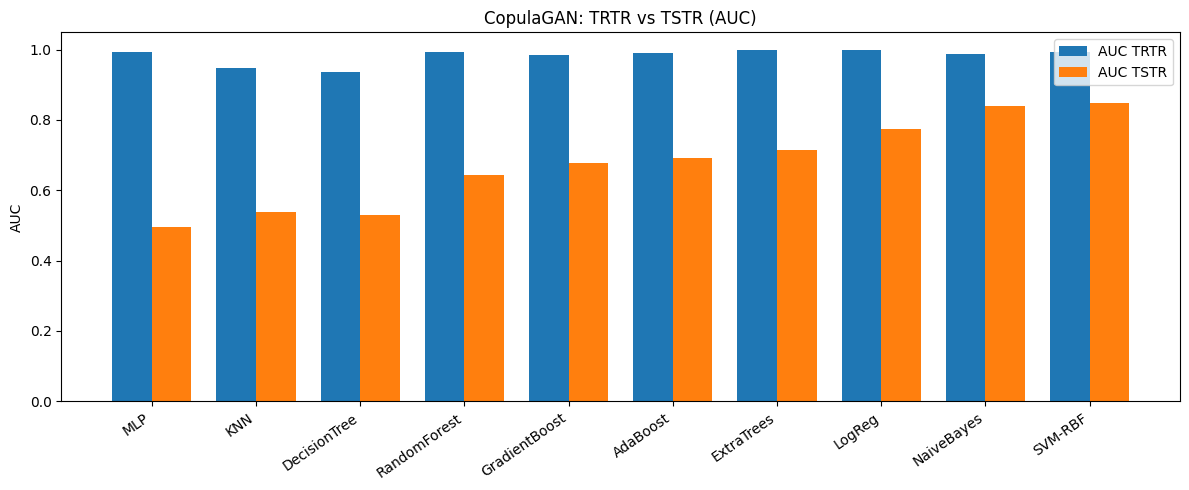

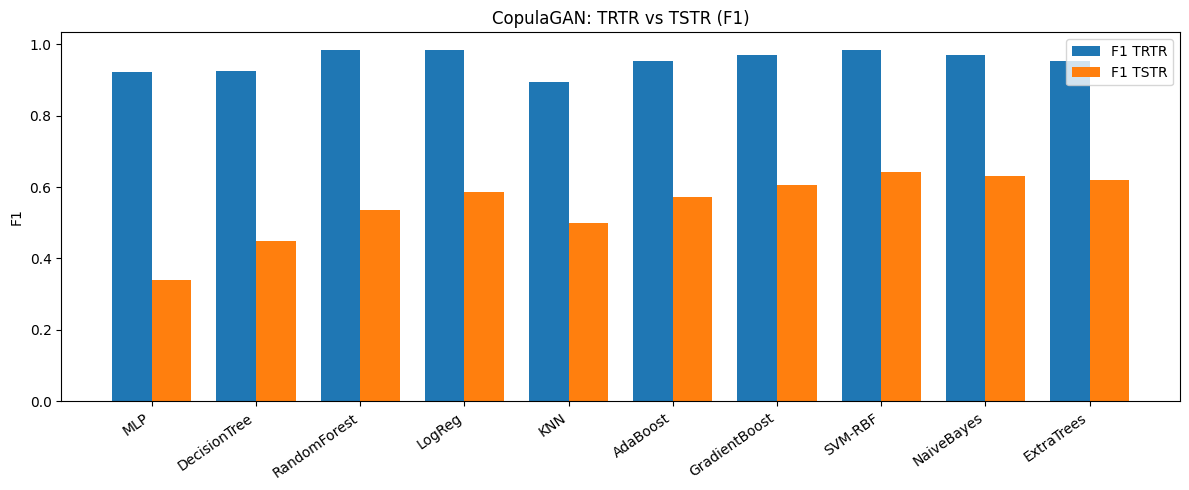

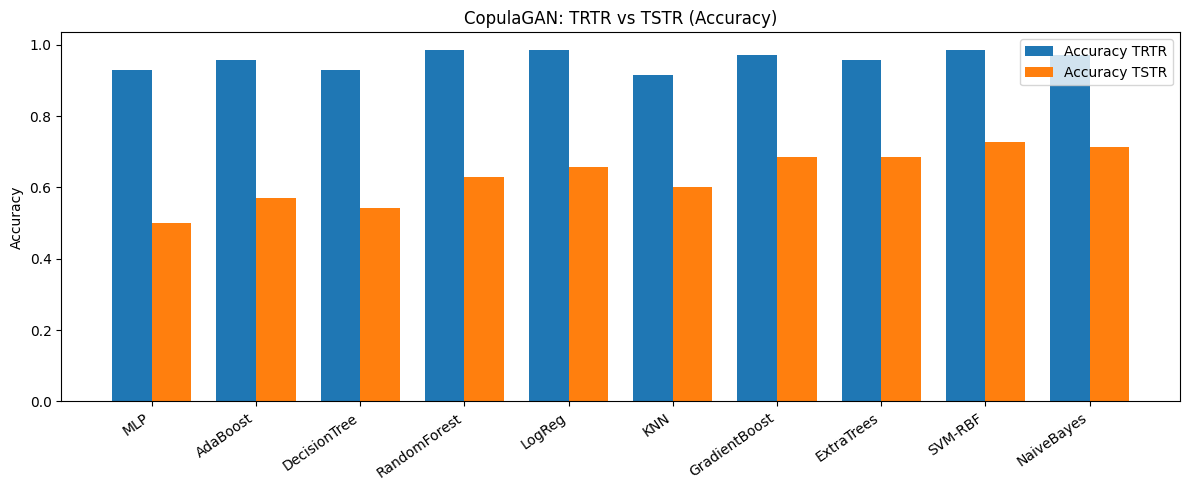

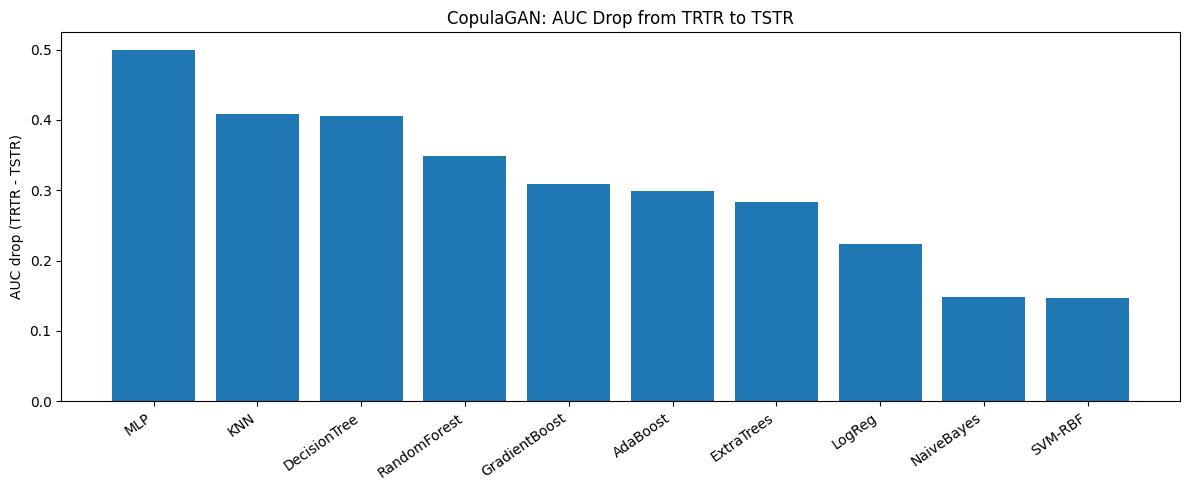


TVAE - TSTR


,Model,Accuracy,F1,AUC
9,MLP,0.785714,0.805195,0.995864
0,LogReg,0.942857,0.939394,0.994210
6,ExtraTrees,0.857143,0.861111,0.994210
5,RandomForest,0.828571,0.837838,0.991729
8,AdaBoost,0.885714,0.885714,0.991729
1,SVM-RBF,0.942857,0.939394,0.990902
3,NaiveBayes,0.971429,0.968750,0.987179
7,GradientBoost,0.828571,0.837838,0.977667
2,KNN,0.914286,0.911765,0.974773
4,DecisionTree,0.700000,0.746988,0.730769


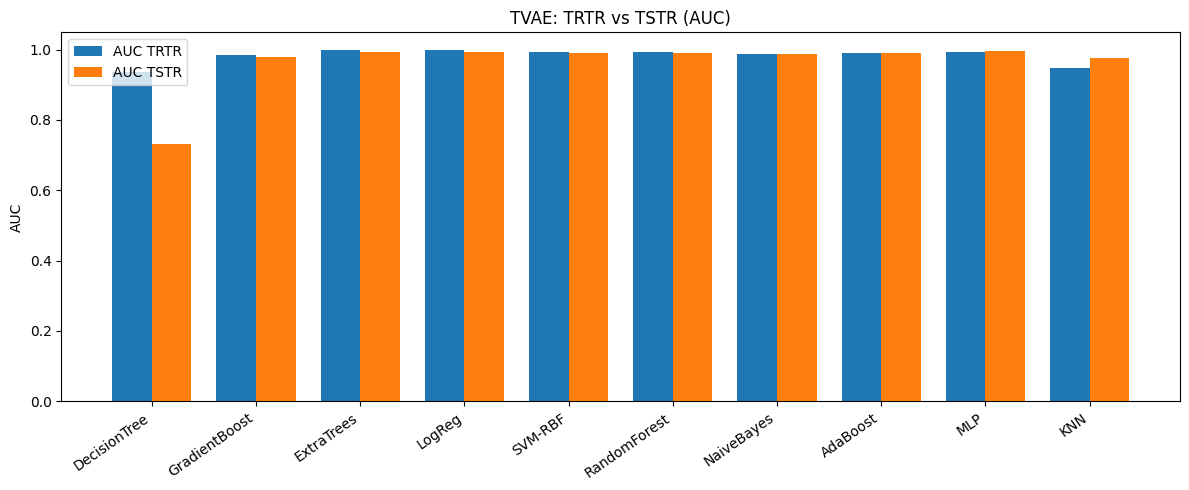

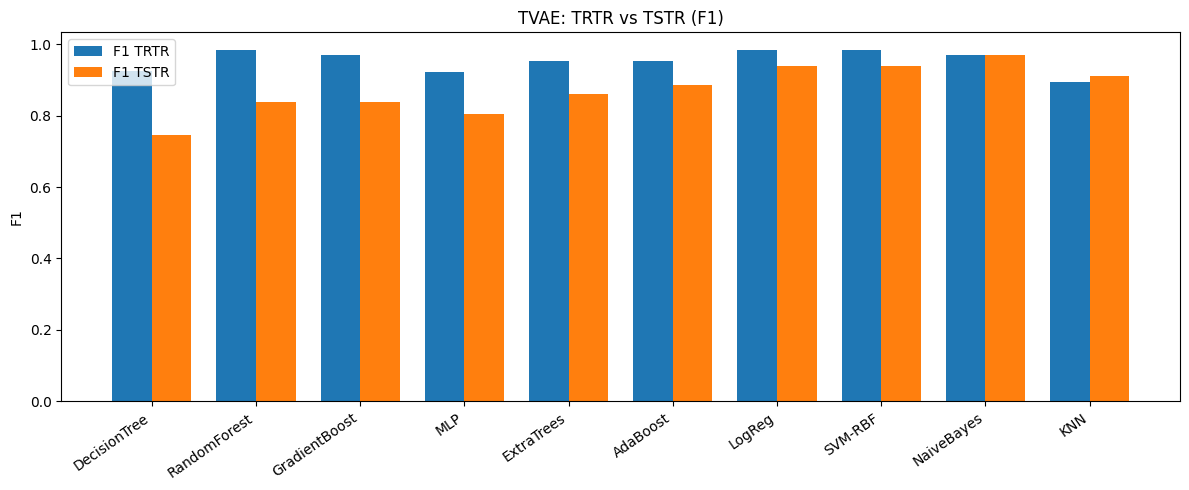

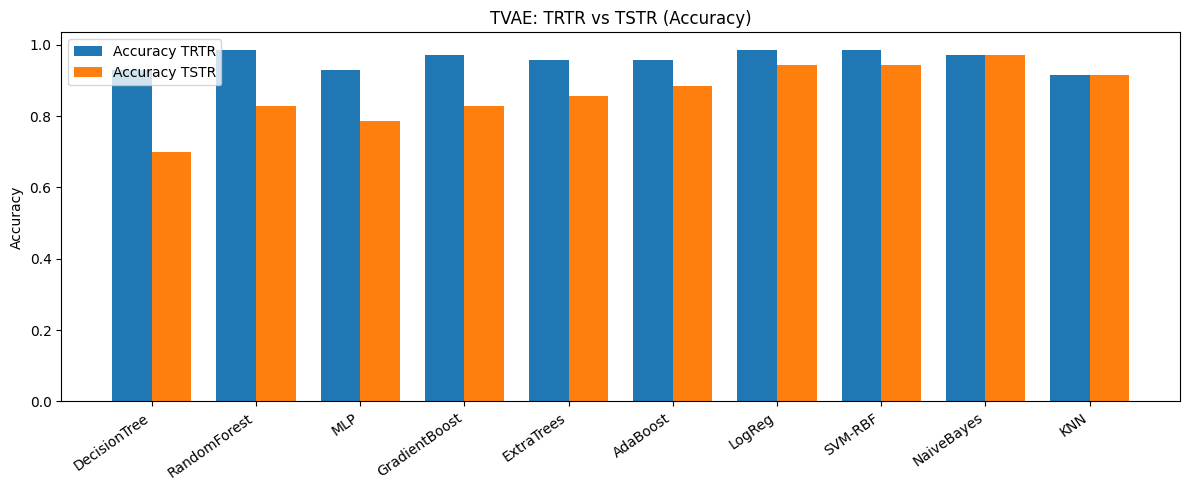

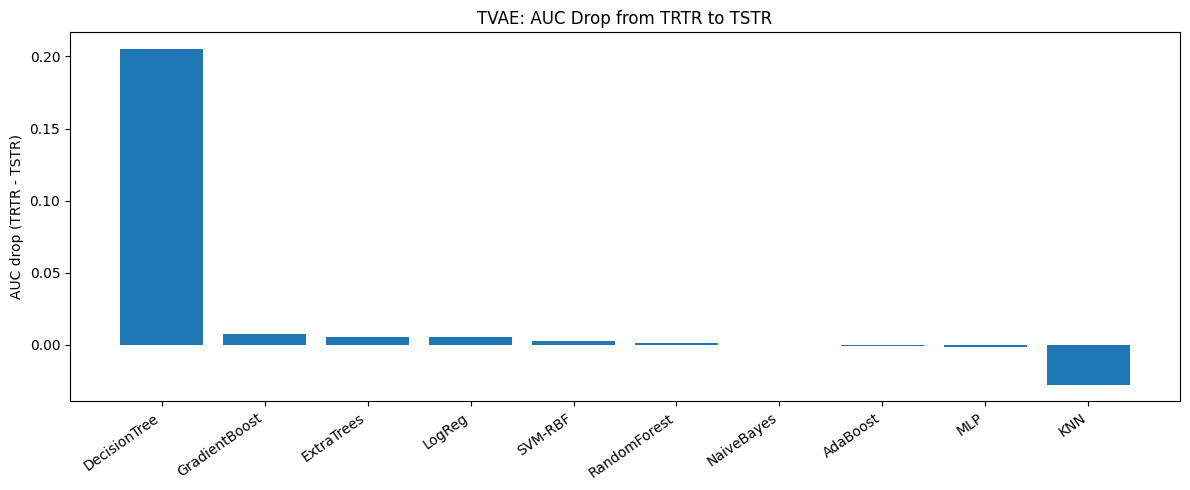


GaussianCopula - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.971429,0.968750,1.000000
0,LogReg,0.971429,0.968750,0.999173
3,NaiveBayes,0.985714,0.984127,0.997519
6,ExtraTrees,0.900000,0.898551,0.990902
5,RandomForest,0.914286,0.911765,0.990902
1,SVM-RBF,0.914286,0.909091,0.981803
7,GradientBoost,0.885714,0.882353,0.975186
2,KNN,0.785714,0.788732,0.915219
9,MLP,0.800000,0.781250,0.864351
4,DecisionTree,0.657143,0.600000,0.649297


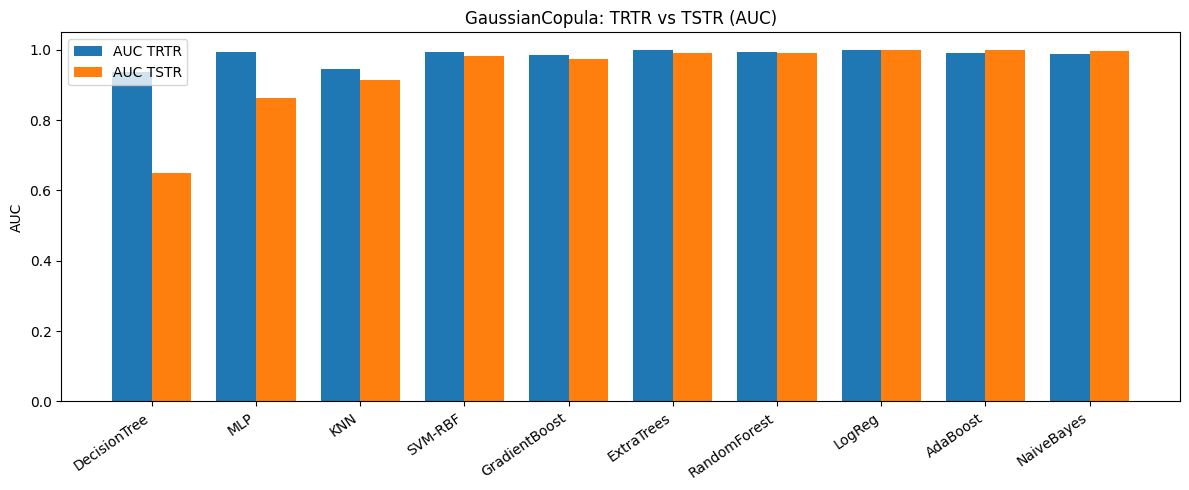

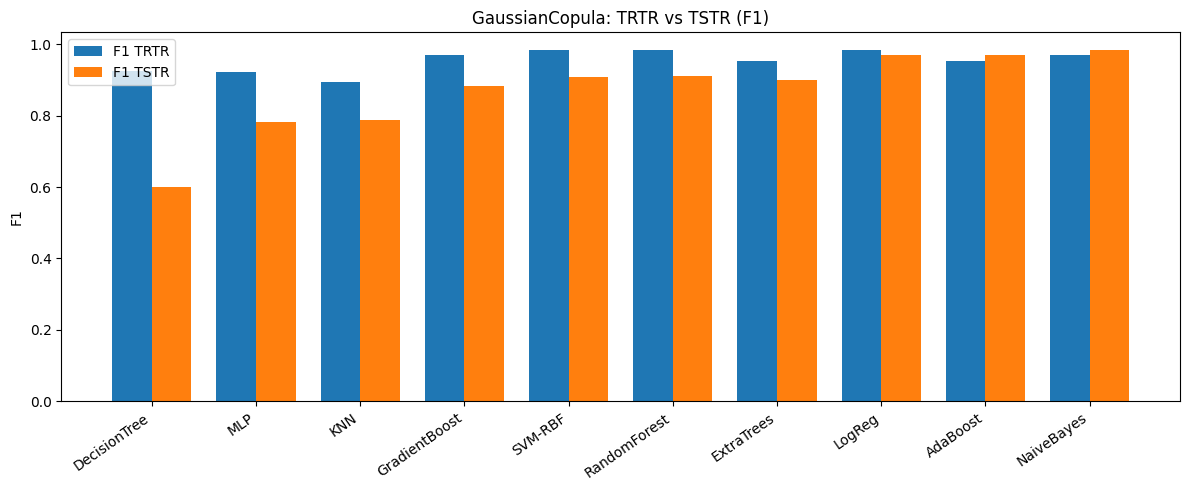

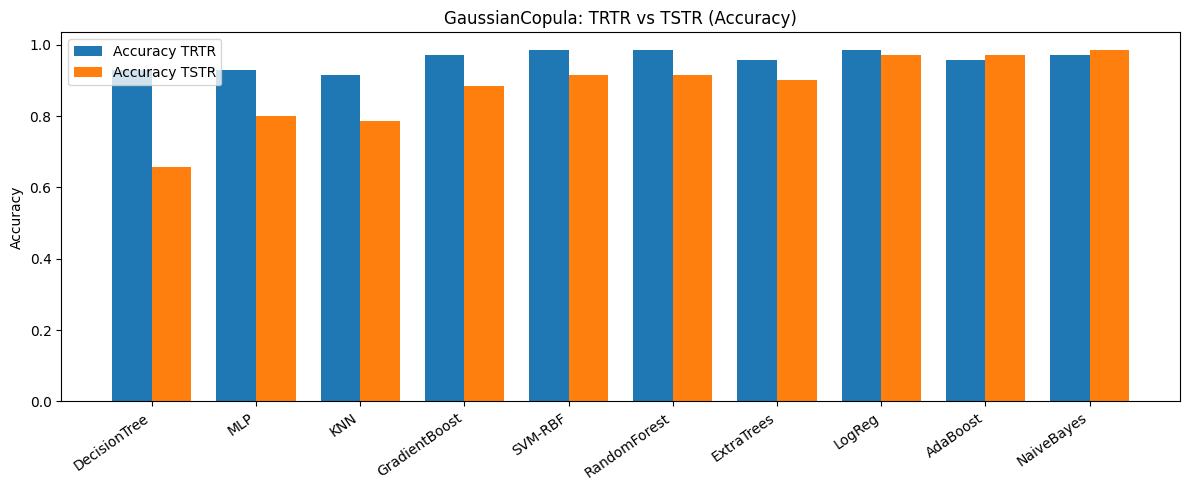

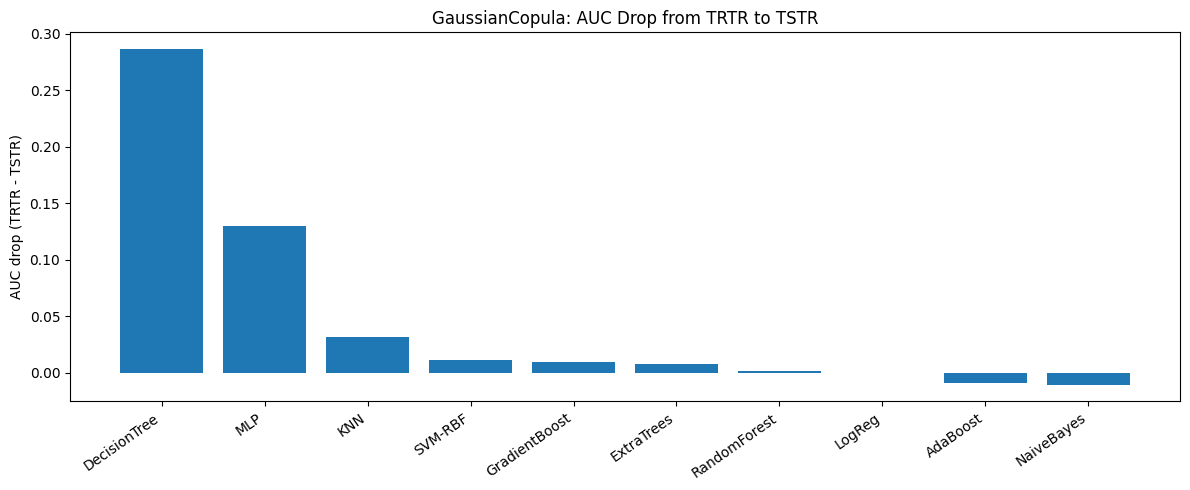


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
3,TVAE,0.019603
2,GaussianCopula,0.046071
1,CopulaGAN,0.307113
0,CTGAN,0.415219


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Group"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=train_real,
    test_df=test_real,
    label_col="Group",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=test_real,
        label_col="Group",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


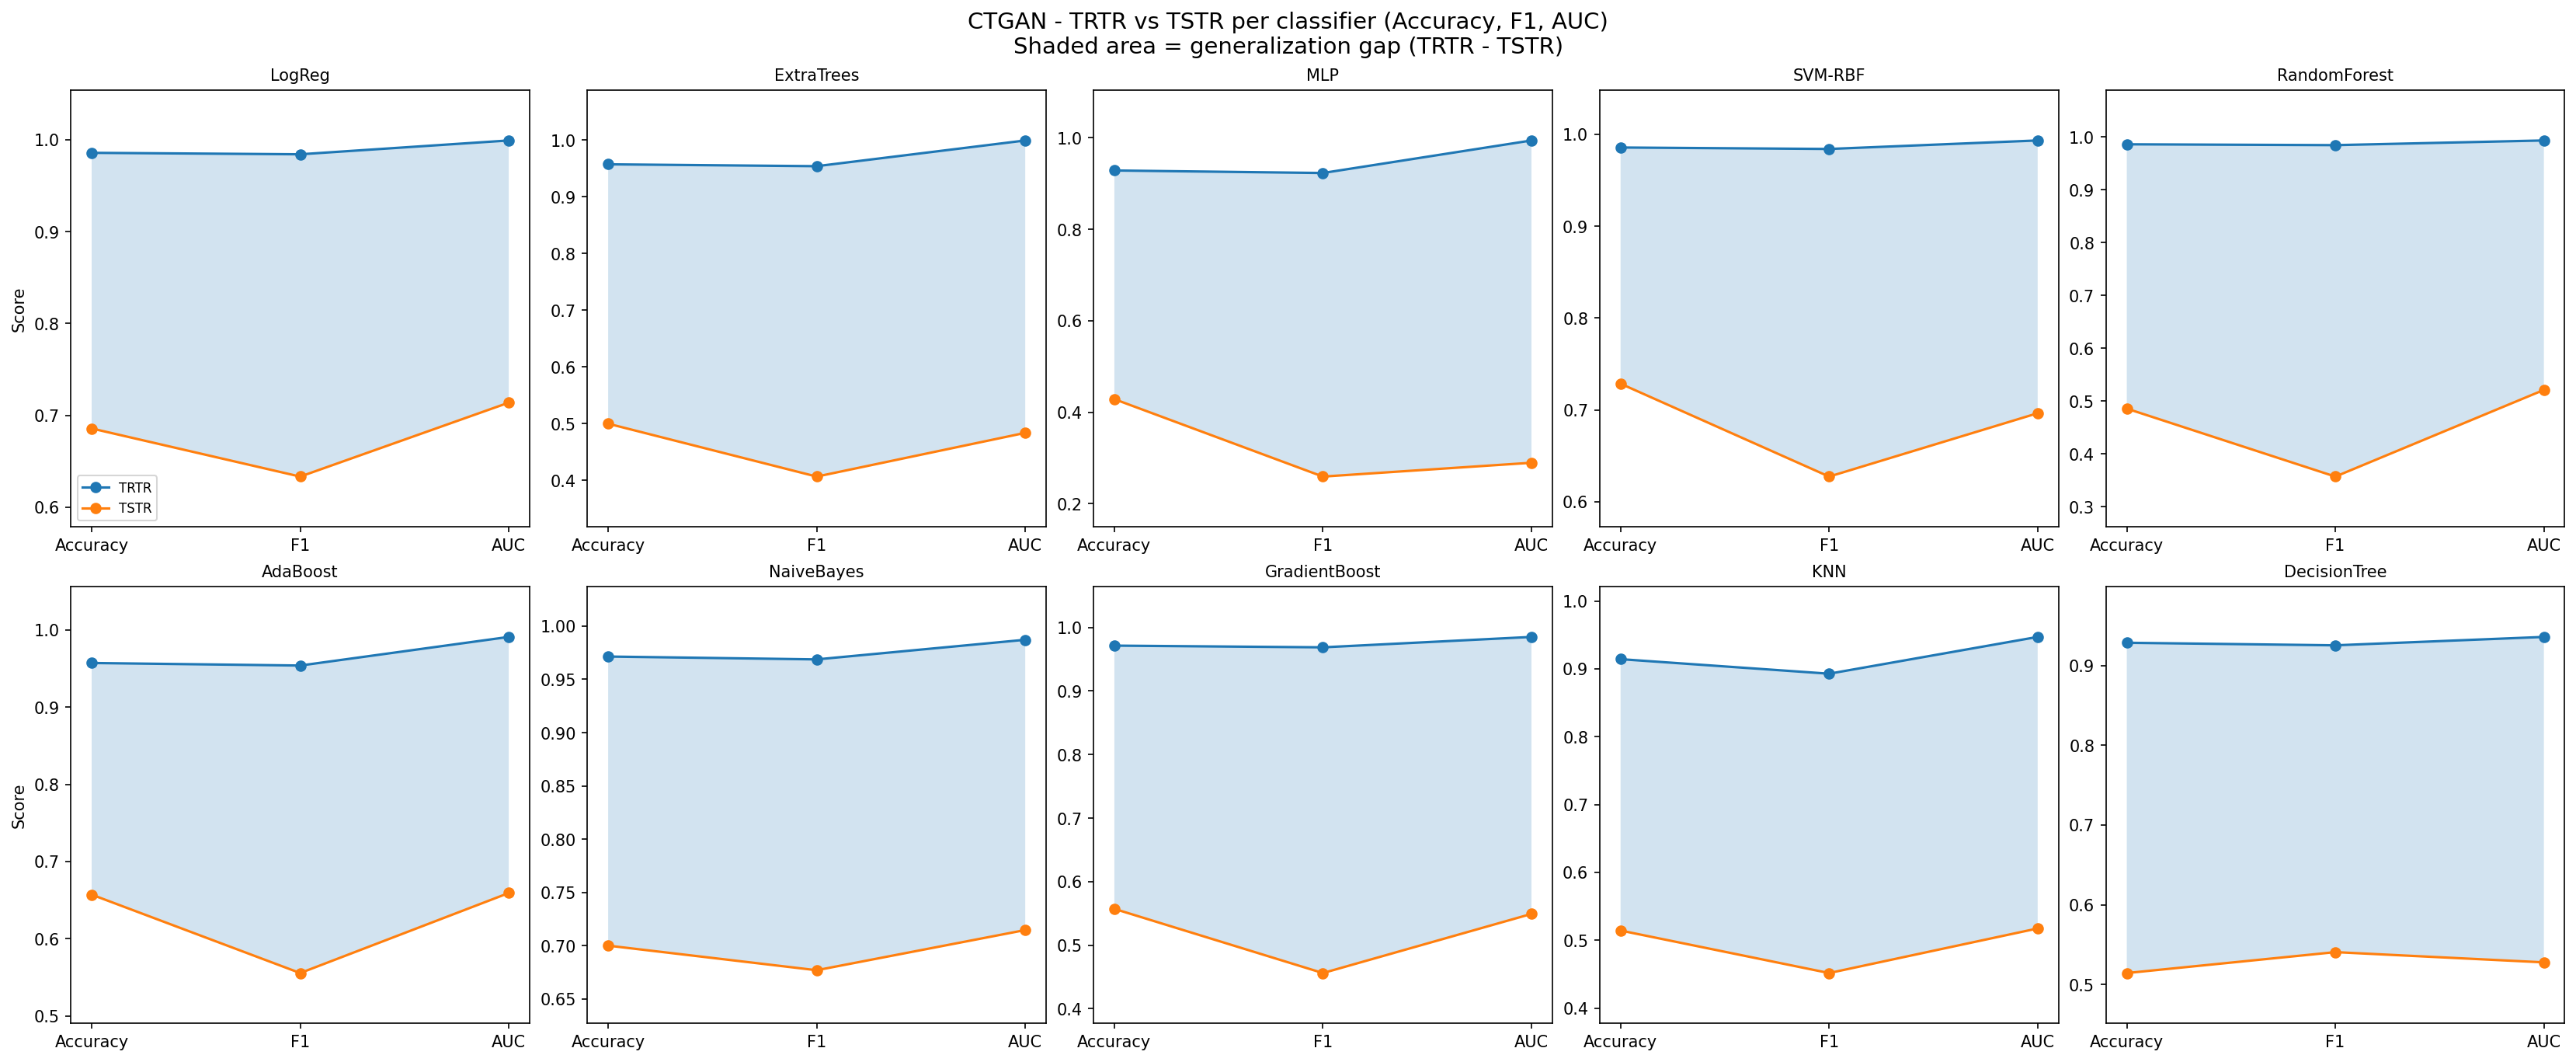

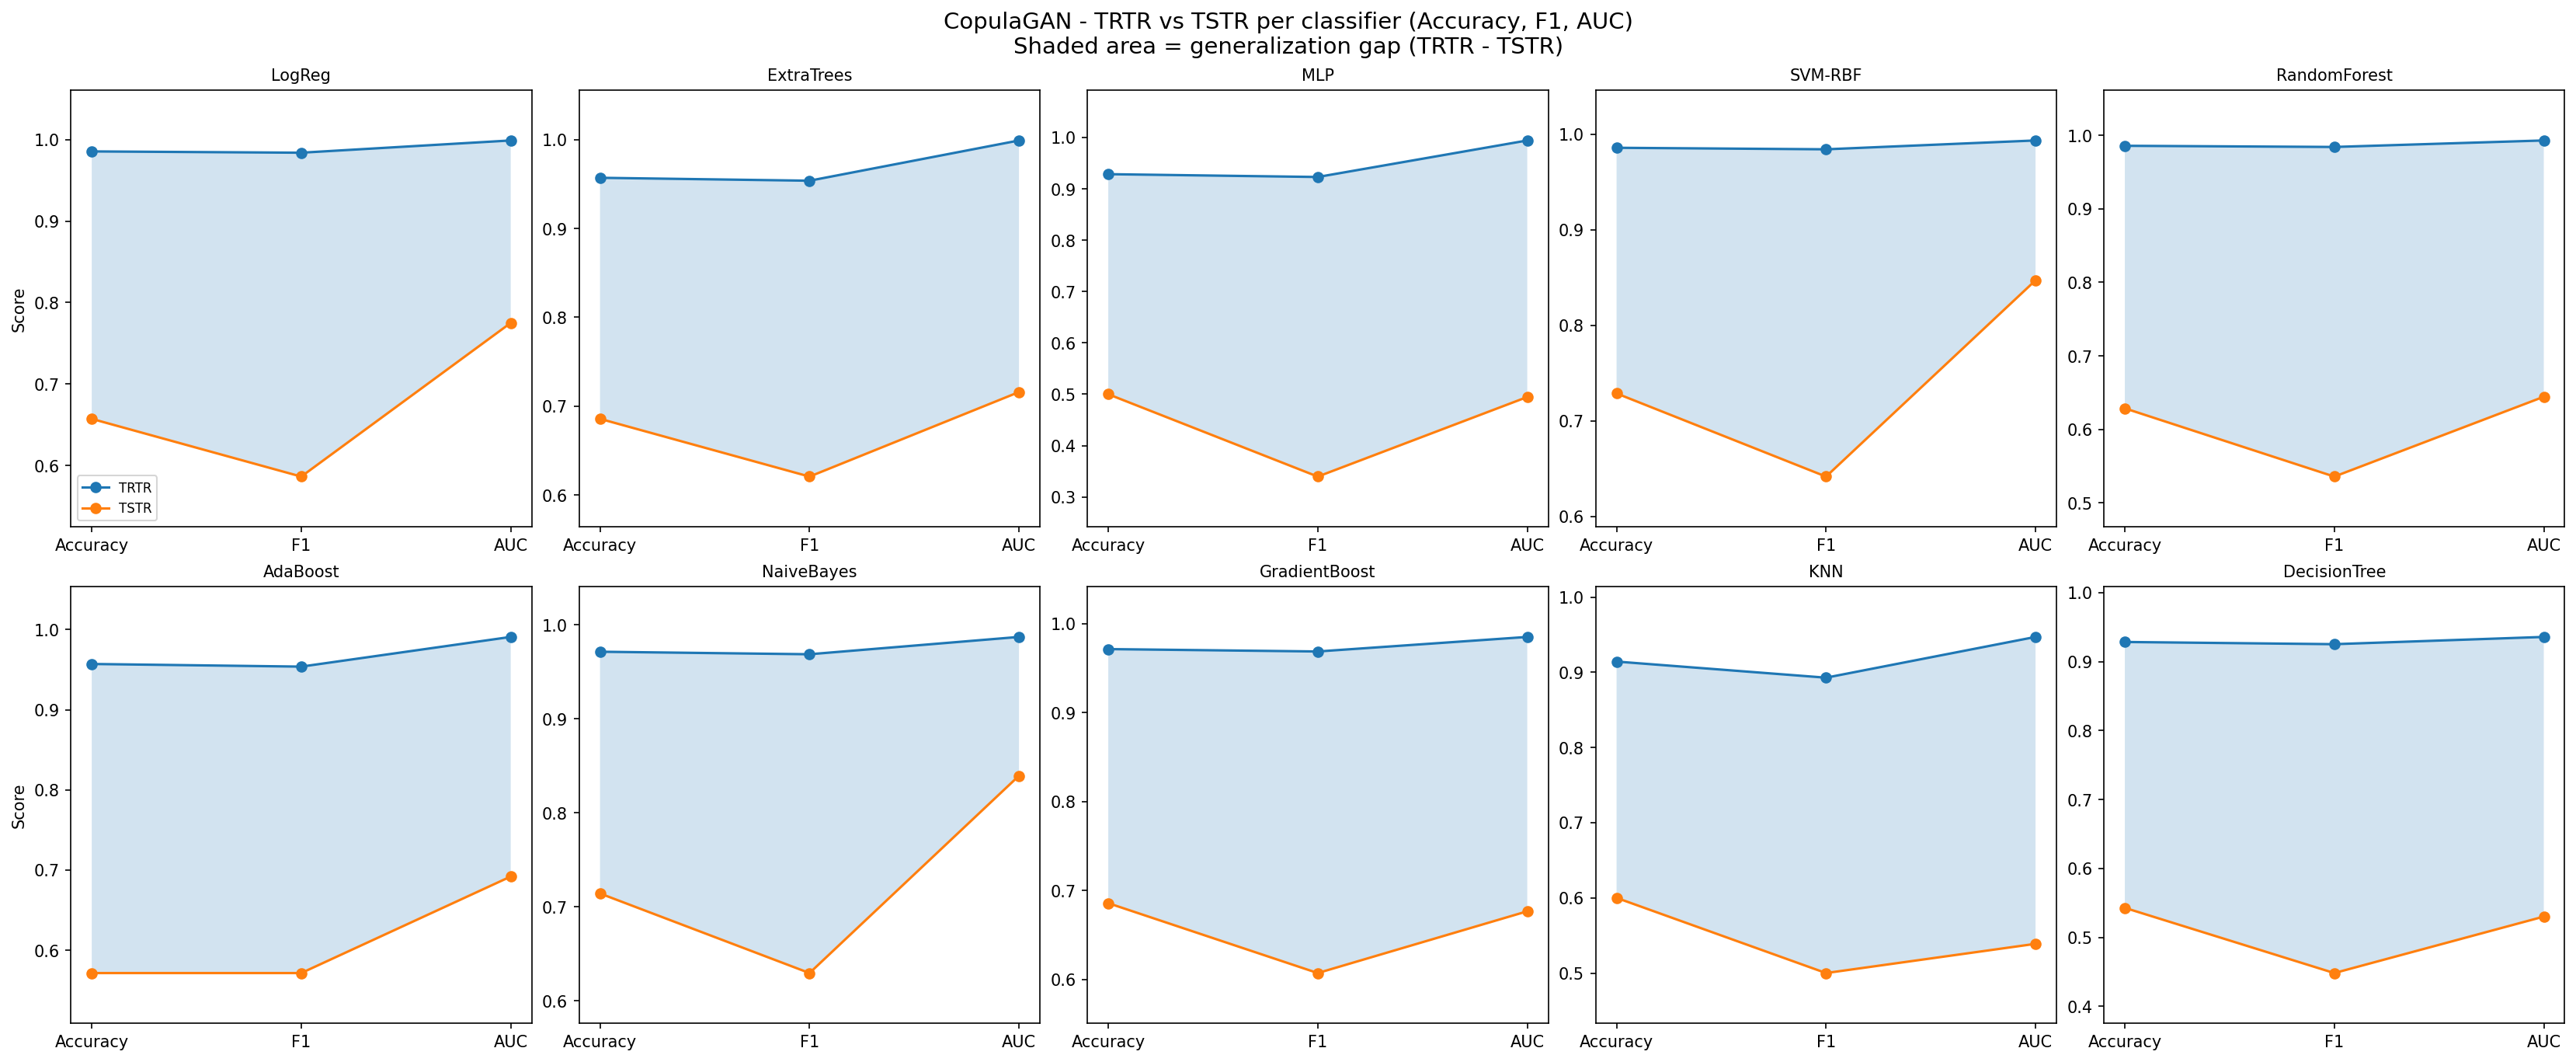

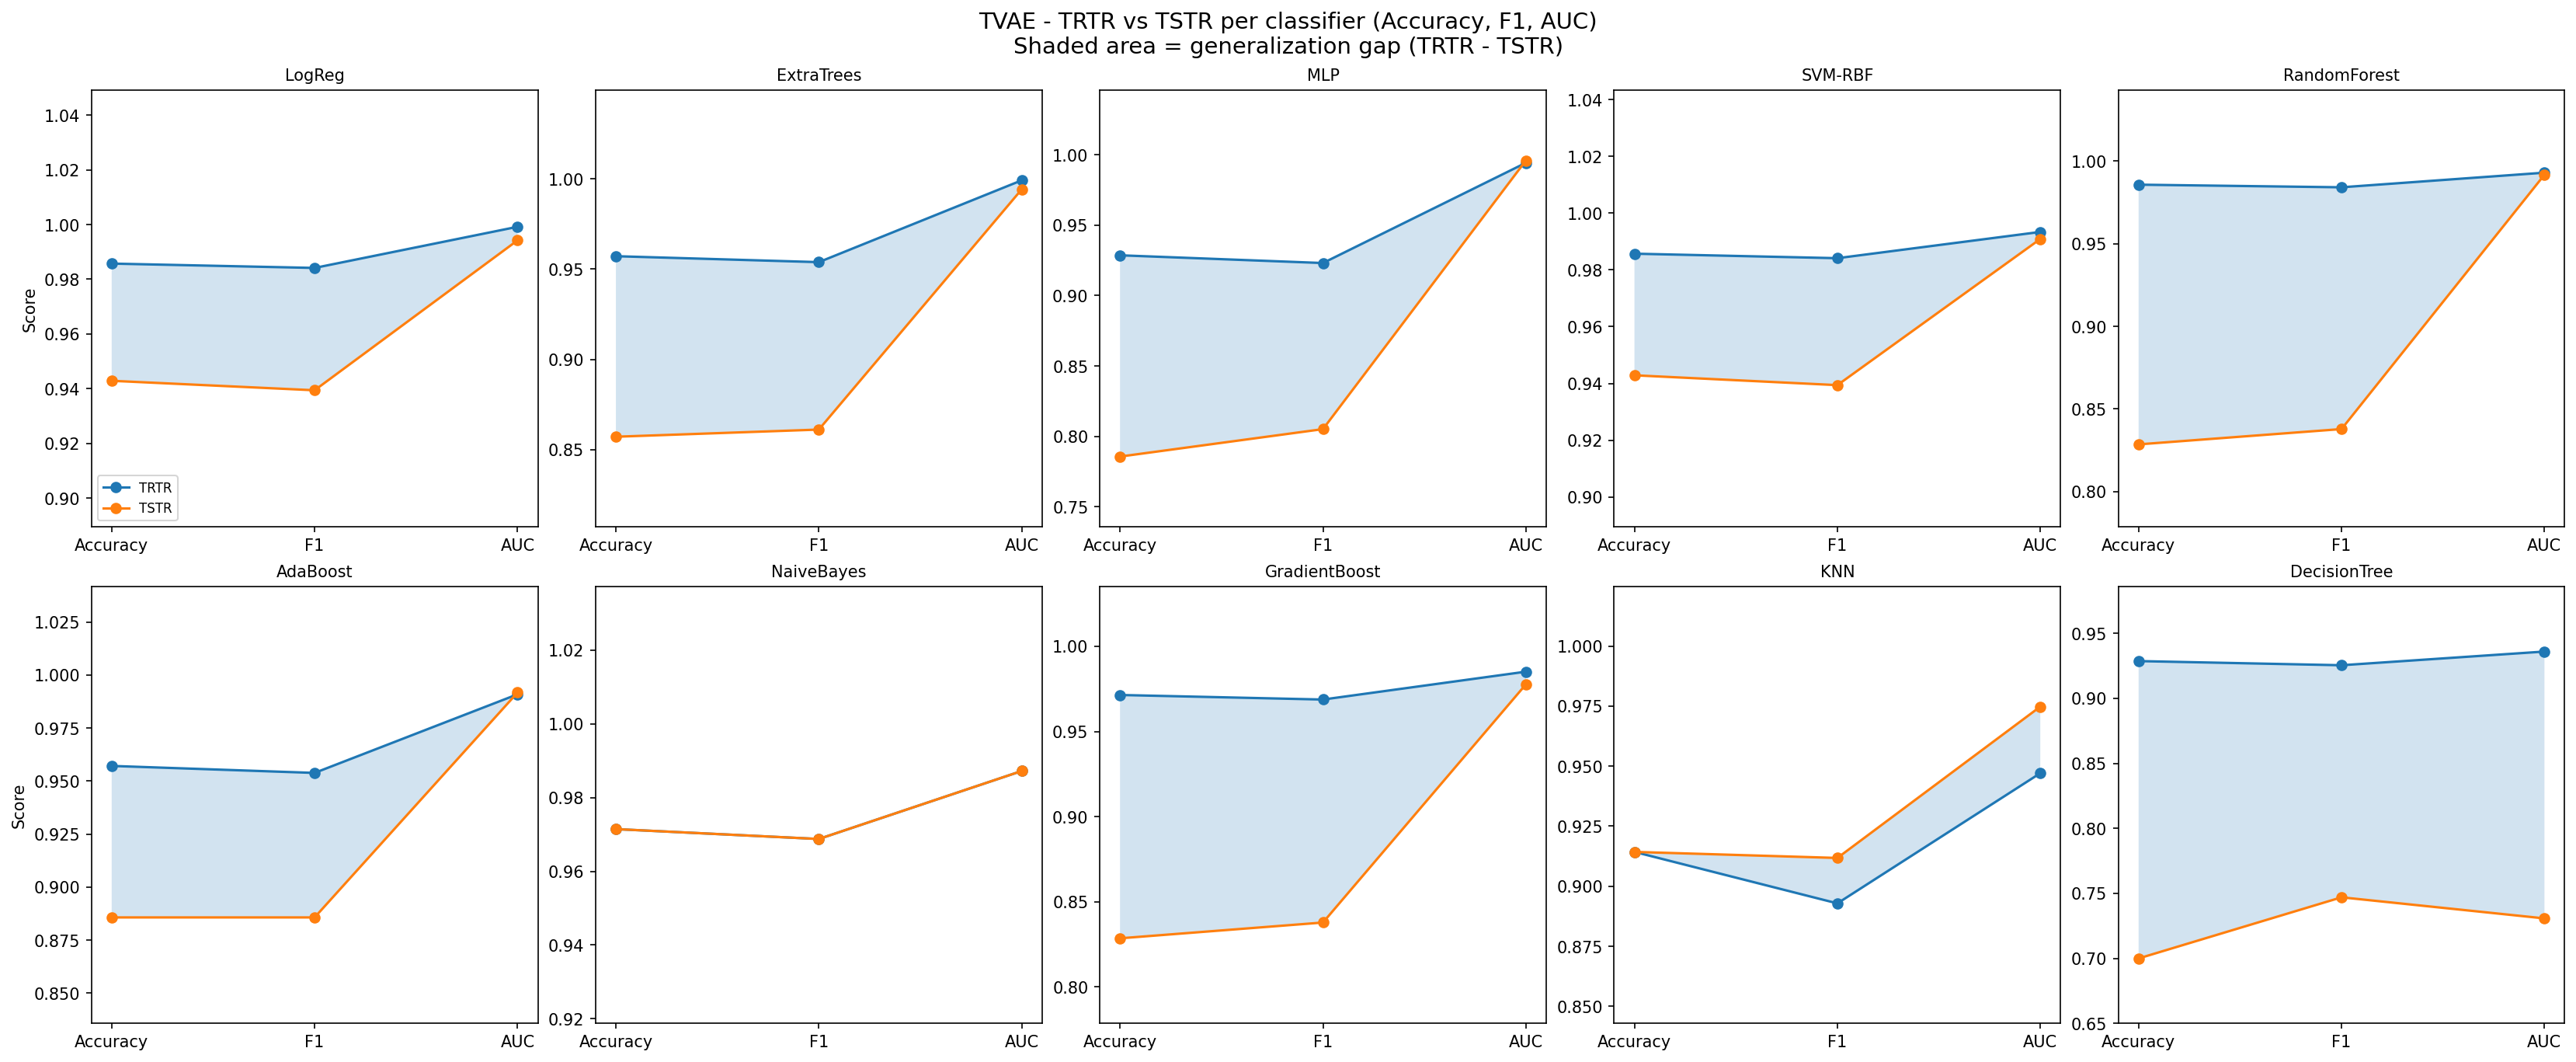

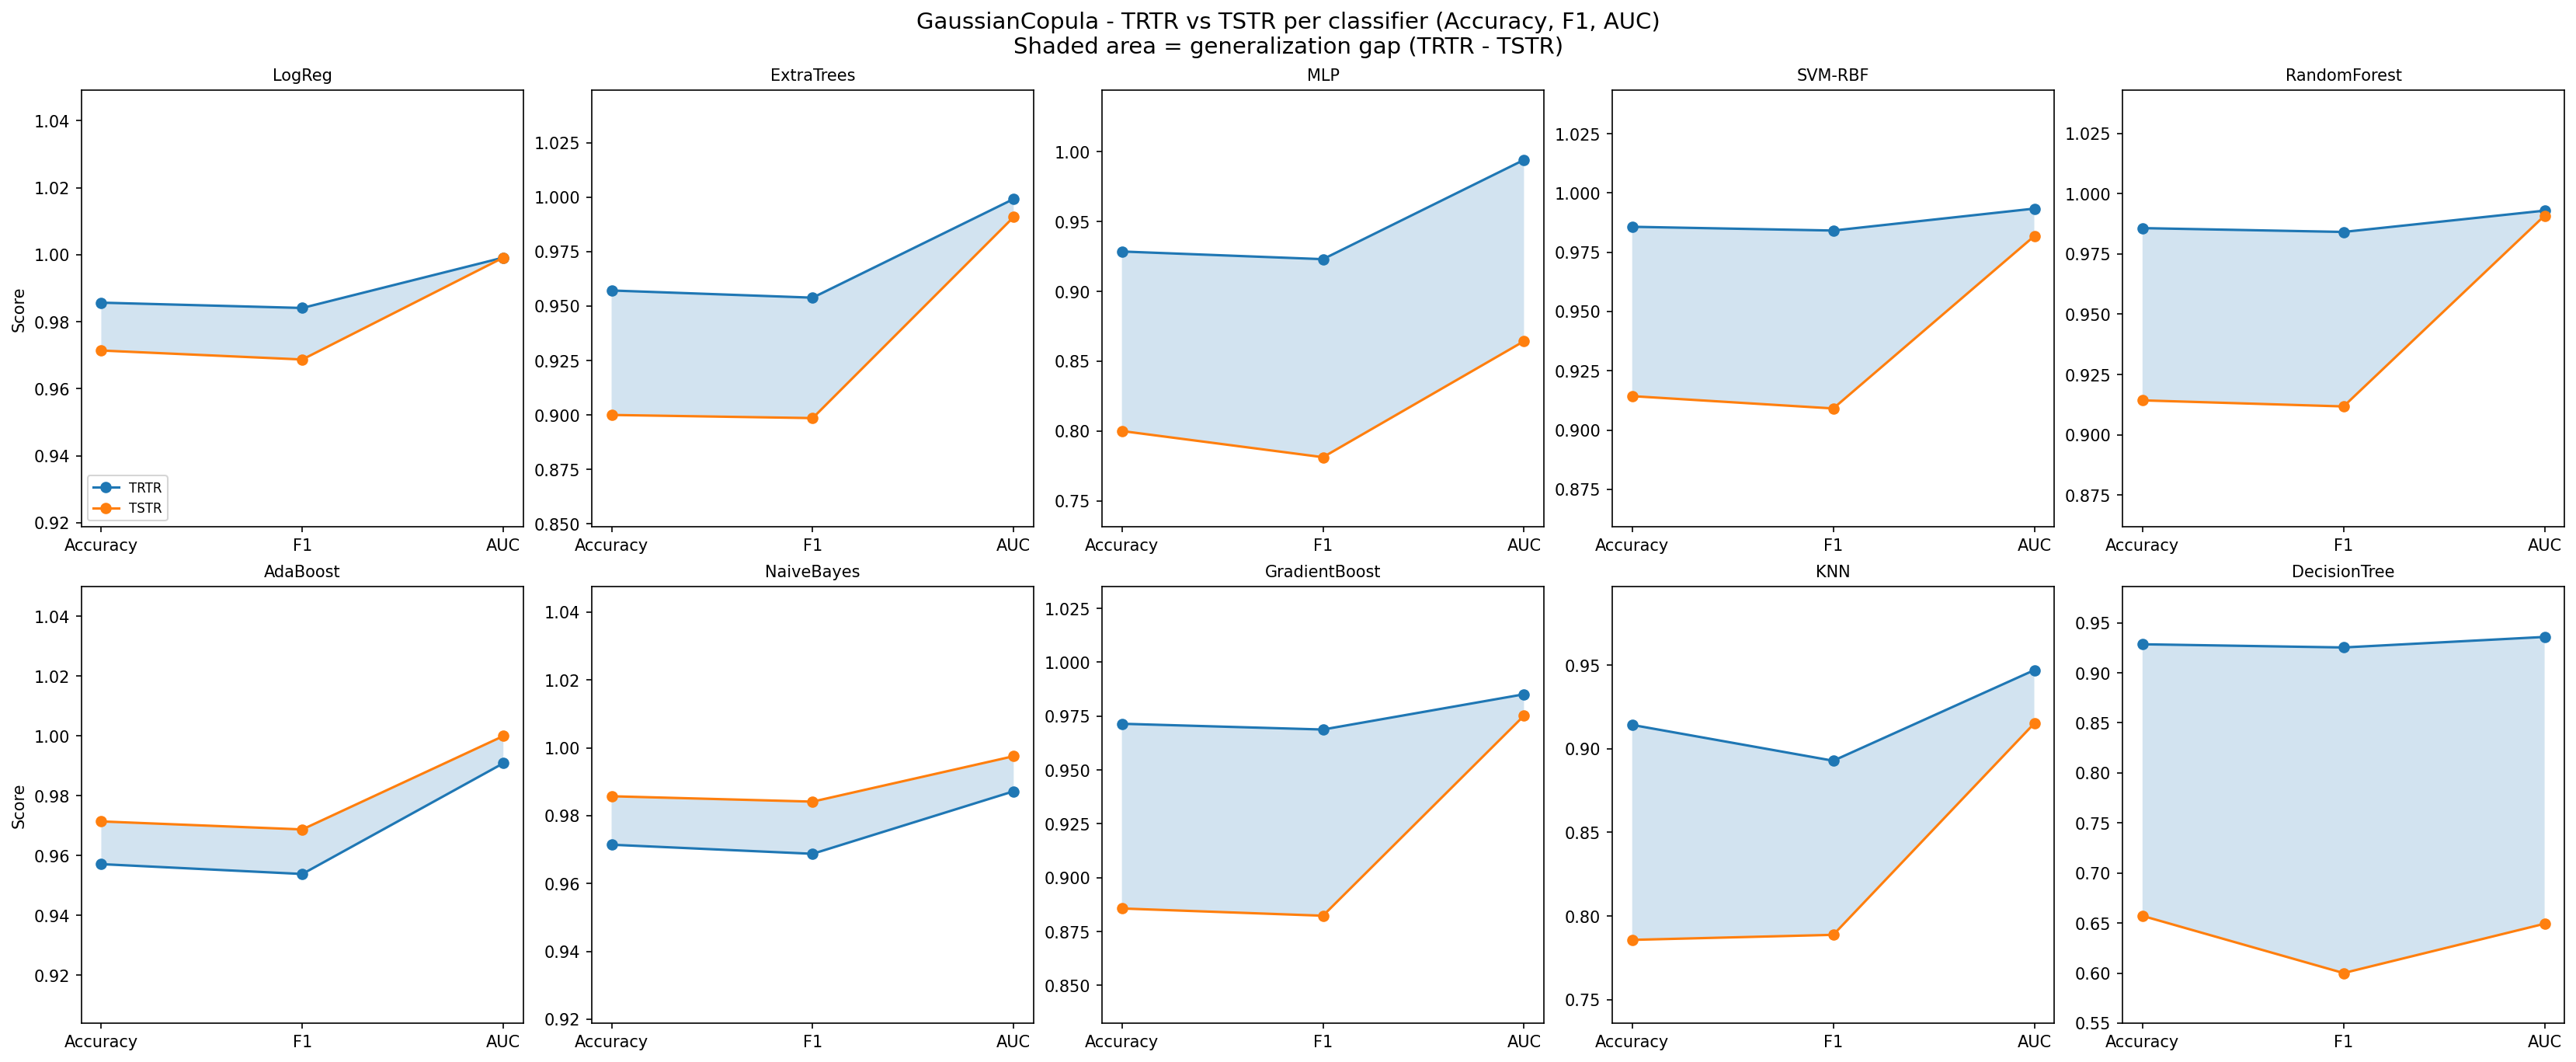

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "Group"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=train_real,
    test_df=test_real,
    label_col="Group",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen],
        test_df=test_real,
        label_col="Group",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests

Outlier-count comparison (IQR rule) between real and synthetic numeric features — same metric as Adult / Other GAN / Diffusion notebooks (`Avg_Abs_Diff_Outlier_Count`).

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,11.1,3.0,36
1,TVAE,29.6,29.5,67
2,GaussianCopula,33.6,6.0,132
3,CopulaGAN,39.9,5.5,245


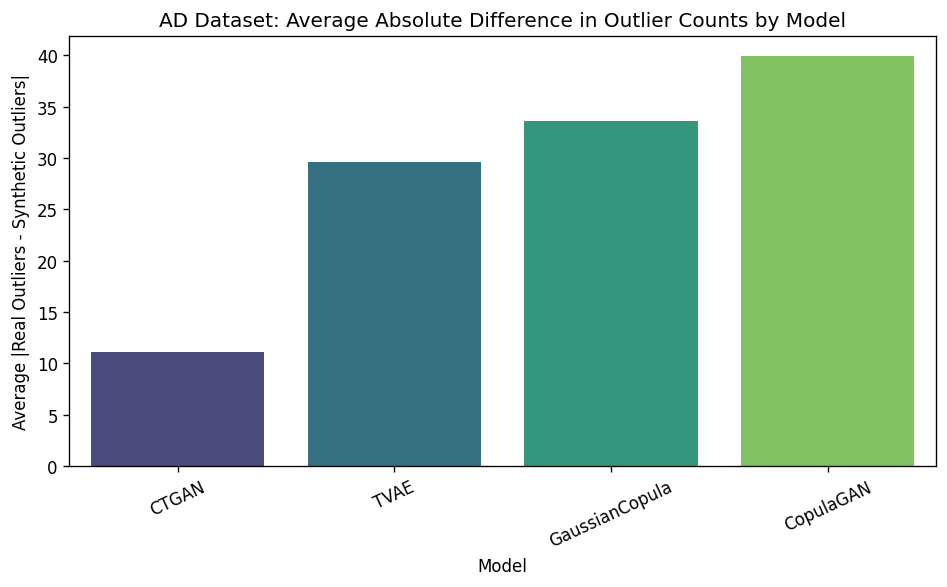

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes:
# - ad_data
# - synthetic_datasets = {"CTGAN": df, "CopulaGAN": df, "TVAE": df, "GaussianCopula": df}

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "Group" in num_cols:
    num_cols.remove("Group")

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols],
    })
    feat_df["Abs_Diff_Outlier_Count"] = (
        feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]
    ).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max(),
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .sort_values("Avg_Abs_Diff_Outlier_Count")
    .reset_index(drop=True)
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    palette="viridis",
)
plt.title("AD Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [26]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

real_data = ad_data.copy()

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(real_data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(real_data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(real_data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(real_data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(real_data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[real_data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = real_data.select_dtypes(include=[np.number]).columns
real_matrix = normalize_rows(real_data[num_cols].to_numpy())

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy())
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.924208  0.498610  0.631567  0.723618  0.999988  0.538801  0.980090   
R2   0.985911  0.678639  0.787941  0.858759  0.975026  0.712416  0.999605   
R3   0.923520  0.498560  0.631690  0.723874  0.999537  0.538611  0.979209   
R4   0.989515  0.869199  0.937502  0.973730  0.861466  0.891349  0.944359   
R5   0.924171  0.498626  0.631624  0.723680  0.999983  0.538814  0.980027   
R6   0.991438  0.864518  0.934095  0.971353  0.866716  0.887190  0.948225   
R7   0.923952  0.498649  0.631722  0.723846  0.999871  0.538772  0.979732   
R8   0.993485  0.854872  0.927269  0.966851  0.875865  0.878255  0.953739   
R9   0.883692  0.985492  0.999959  0.993161  0.638339  0.992335  0.777905   
R10  0.923746  0.498609  0.631717  0.723875  0.999716  0.538701  0.979480   

           S8        S9       S10  
R1   0.962250  0.999966  0.983959  
R2   0.998636  0.975003  0.998

,avg_cosine,max_cosine
CTGAN,0.913944,0.999999
CopulaGAN,0.854596,1.000000
TVAE,0.905976,1.000000
GaussianCopula,0.906851,1.000000


In [27]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = ad_data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R156 -> S172   cosine similarity = 1.0000
02. R144 -> S189   cosine similarity = 1.0000
03. R171 -> S227   cosine similarity = 1.0000
04. R98 -> S253   cosine similarity = 1.0000
05. R214 -> S166   cosine similarity = 1.0000
06. R74 -> S206   cosine similarity = 1.0000
07. R114 -> S33   cosine similarity = 1.0000
08. R232 -> S32   cosine similarity = 1.0000
09. R126 -> S45   cosine similarity = 1.0000
10. R173 -> S227   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R242 -> S241   cosine similarity = 1.0000
02. R200 -> S241   cosine similarity = 1.0000
03. R110 -> S152   cosine similarity = 1.0000
04. R50 -> S258   cosine similarity = 1.0000
05. R255 -> S134   cosine similarity = 1.0000
06. R212 -> S241   cosine similarity = 1.0000
07. R179 -> S33   cosine similarity = 1.0000
08. R157 -> S110   cosine similarity = 1.0000
09. R227 -> S259   cosine similarity = 1.0000
10. R154 -> S253   cosine similarity = 1.

In [28]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = ad_data.copy()

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN": CTGANSynthesizer,
    "CopulaGAN": CopulaGANSynthesizer,
    "TVAE": TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))[real_df.columns]

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

Fitting GaussianCopula...


Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9543

R121 <-> S250   cosine similarity = 1.0000
R203 <-> S227   cosine similarity = 1.0000
R10 <-> S187   cosine similarity = 1.0000
R52 <-> S61   cosine similarity = 1.0000
R236 <-> S274   cosine similarity = 1.0000
R187 <-> S180   cosine similarity = 1.0000
R110 <-> S278   cosine similarity = 1.0000
R101 <-> S42   cosine similarity = 1.0000
R259 <-> S74   cosine similarity = 1.0000
R156 <-> S165   cosine similarity = 1.0000

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9857

R74 <-> S112   cosine similarity = 1.0000
R163 <-> S252   cosine similarity = 1.0000
R24 <-> S34   cosine similarity = 1.0000
R273 <-> S157   cosine similarity = 1.0000
R160 <-> S216   cosine similarity = 1.0000
R62 <-> S97   cosine similarity = 1.0000
R230 <-> S254   cosine similarity = 1

In [29]:
import pandas as pd
import numpy as np

real_df = ad_data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_AD.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            continue
        if model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Hungarian_Matchings_All_Models_AD.xlsx


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
2,TVAE,284,0.993816,0.997842,0.960915,0.999999
0,CTGAN,284,0.985716,0.996700,0.944991,0.999999
3,GaussianCopula,284,0.954315,0.954958,0.878468,1.000000
1,CopulaGAN,284,0.903369,0.880242,0.731328,0.999997


# 7. Mahalanobis distance with Hungrain Mapping

In [30]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

data_numeric = ad_data.select_dtypes(include=[np.number]).dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (11,), Inv_cov shape: (11, 11)


In [31]:
mahalanobis_results = {}
num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=float)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,4.315918,4.023903,1.392085,1.716255,9.154950
TVAE,5.592197,4.920136,2.853619,1.907693,19.189803
CTGAN,11.275909,10.098609,5.558303,3.344832,37.809685
CopulaGAN,13.288068,12.471935,5.699119,2.943645,33.178038


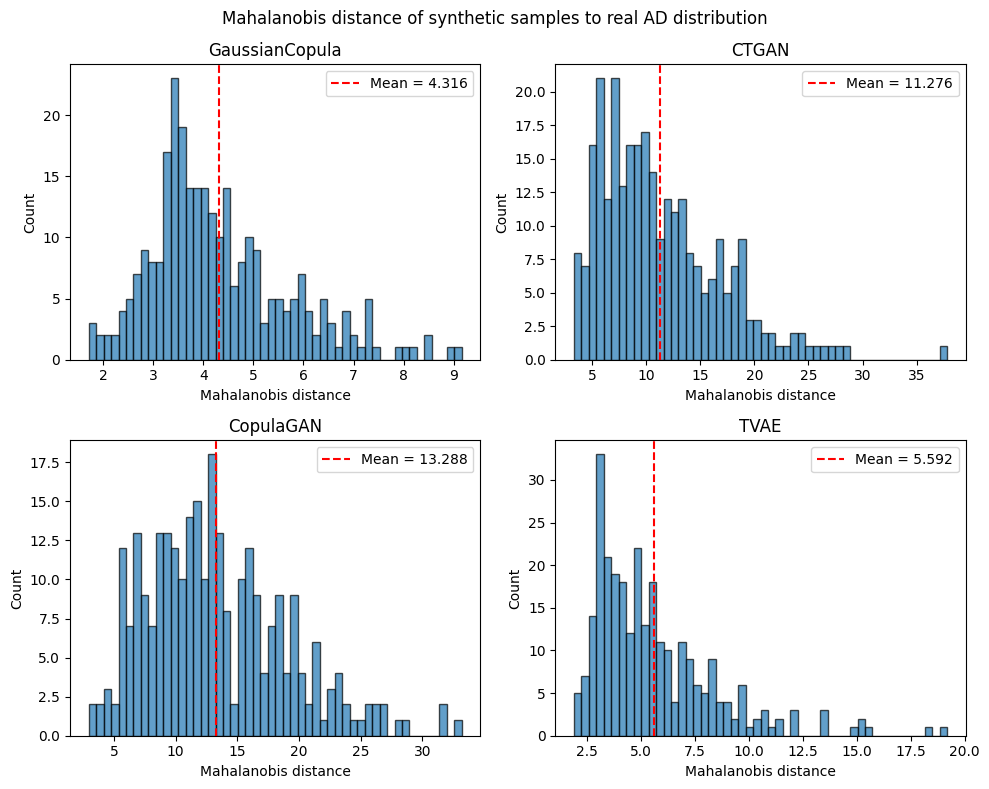

In [32]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real AD distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_ad_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [33]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = ad_data[num_cols].to_numpy(dtype=float)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,3.421645,3.307327,1.489640,9.924125
TVAE,4.593258,3.772781,2.913000,17.085634
CTGAN,9.993690,8.642553,5.544680,33.386372
CopulaGAN,11.991024,10.952678,5.841983,32.591759


In [34]:
# Greedy mapping 
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = ad_data[num_cols].to_numpy(dtype=float)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy - Hungarian)": total_g - h_total,
        "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance):")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
GaussianCopula,1050.619698,3.699365
CTGAN,2903.375428,10.223153
CopulaGAN,3483.388697,12.265453
TVAE,1367.333825,4.814556



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
GaussianCopula,1050.619698,971.747258,3.699365,3.421645,78.872440,0.277720
CTGAN,2903.375428,2838.207889,10.223153,9.993690,65.167539,0.229463
CopulaGAN,3483.388697,3405.450829,12.265453,11.991024,77.937868,0.274429
TVAE,1367.333825,1304.485190,4.814556,4.593258,62.848635,0.221298


In [35]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=float)
    S = synth_df[feature_cols].to_numpy(dtype=float)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=float), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = ad_data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=float)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 10
GaussianCopula: avg matched Mahalanobis distance = 3.1525
CTGAN: avg matched Mahalanobis distance = 9.7485
CopulaGAN: avg matched Mahalanobis distance = 11.6828
TVAE: avg matched Mahalanobis distance = 4.4894


In [36]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
real_df = ad_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    hungarian_results[model_name] = {"row_ind": row_ind, "col_ind": col_ind, "dists": dists}

    order = np.argsort(dists)
    top_k = min(20, len(order))

    print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
    for rank, k in enumerate(order[:top_k], 1):
        print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")


CTGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R150 -> S29   distance = 1.1507
02. R189 -> S276   distance = 1.4978
03. R279 -> S247   distance = 1.8680
04. R218 -> S184   distance = 2.1770
05. R130 -> S172   distance = 2.1920
06. R241 -> S278   distance = 2.2370
07. R166 -> S222   distance = 2.3225
08. R112 -> S163   distance = 2.5986
09. R105 -> S144   distance = 2.7202
10. R90 -> S40   distance = 2.7554
11. R250 -> S27   distance = 2.7723
12. R225 -> S120   distance = 2.7900
13. R236 -> S179   distance = 2.8514
14. R116 -> S77   distance = 2.8846
15. R142 -> S68   distance = 2.9969
16. R98 -> S262   distance = 3.1080
17. R35 -> S53   distance = 3.1522
18. R28 -> S173   distance = 3.1532
19. R195 -> S203   distance = 3.1944
20. R103 -> S201   distance = 3.2218

CopulaGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R272 -> S167   distance = 1.6873
02. R50 -> S33   distance = 2.1429
03. R64 -> S214   distance = 2.3958
04. R202 -> S150   dista

In [37]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
real_df = ad_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S260   distance = 19.0207
R2 -> S136   distance = 17.6836
R3 -> S128   distance = 12.3281
R4 -> S241   distance = 8.6415
R5 -> S133   distance = 8.0238
R6 -> S92   distance = 4.6791
R7 -> S110   distance = 11.2632
R8 -> S22   distance = 5.2063
R9 -> S65   distance = 4.9654
R10 -> S229   distance = 7.7093
R11 -> S237   distance = 12.5841
R12 -> S108   distance = 25.9907
R13 -> S51   distance = 4.1197
R14 -> S23   distance = 13.4392
R15 -> S145   distance = 9.9274
R16 -> S271   distance = 14.6082
R17 -> S194   distance = 8.9413
R18 -> S134   distance = 8.7100
R19 -> S90   distance = 25.1871
R20 -> S28   distance = 9.9355

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S254   distance = 13.1483
R2 -> S282   distance = 11.4169
R3 -> S98   distance = 3.5232
R4 -> S219   distance = 5.2951
R5 -> S31   distance = 17.9345
R6 -> S45   distance = 8.9101
R7 -> S78   distance = 25.9901
R8 -> S271   distance = 9.8580
R9 -> S170   distance = 10.57

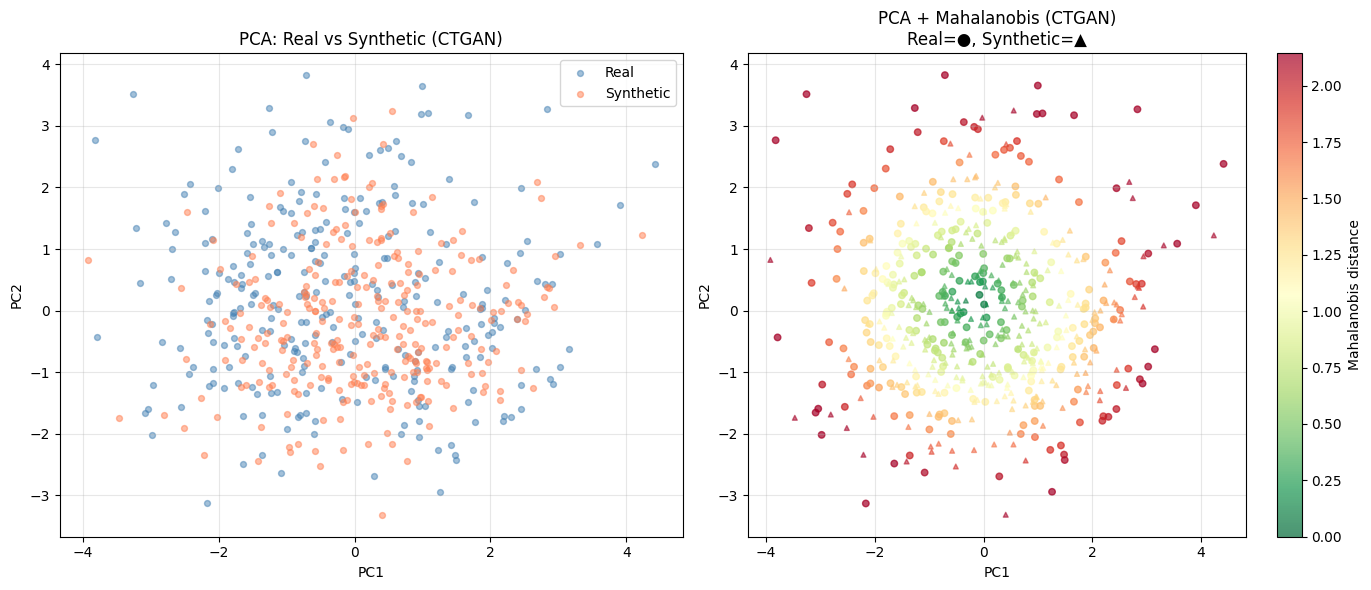

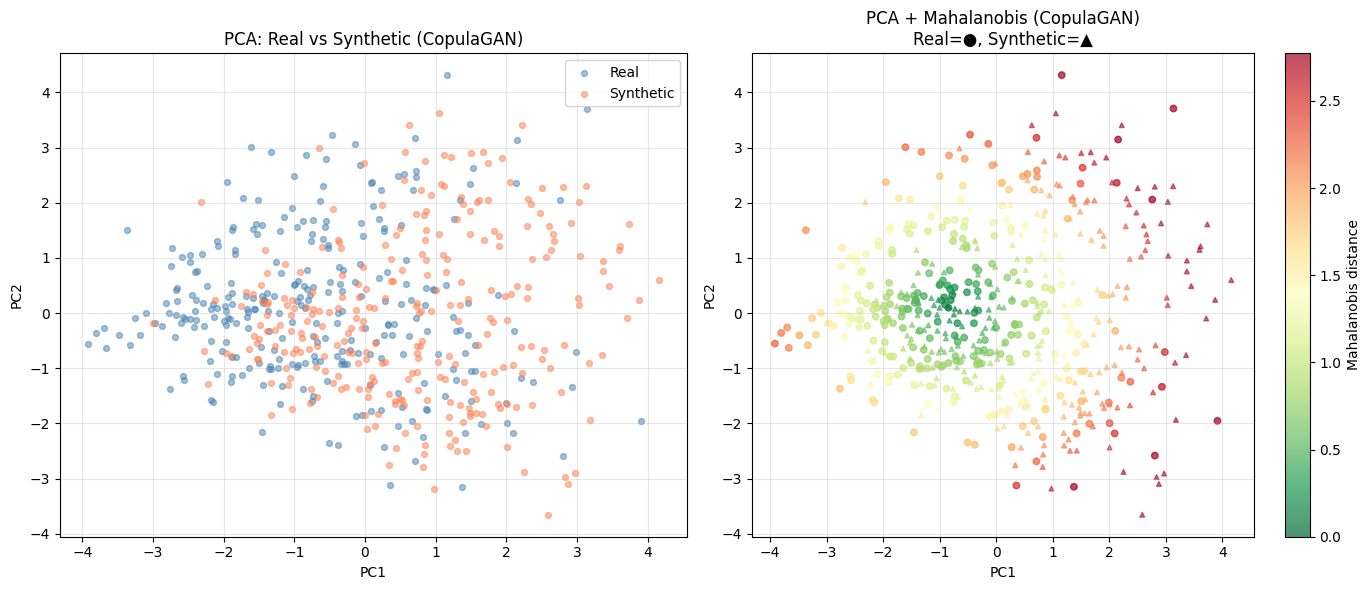

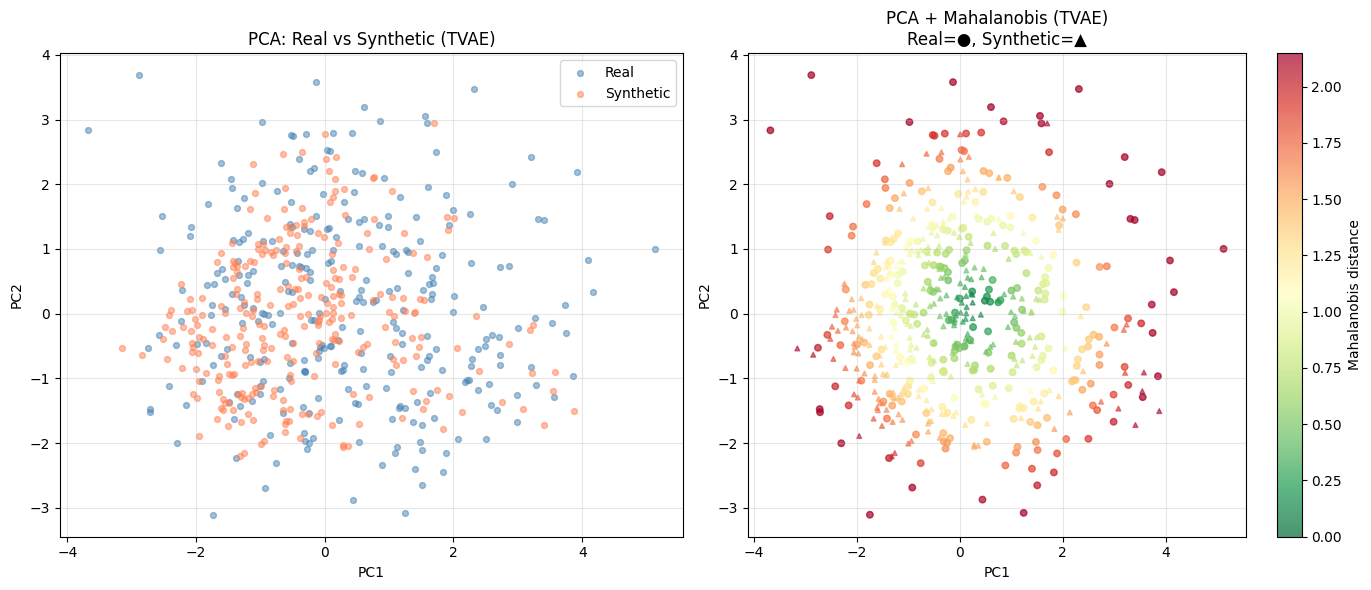

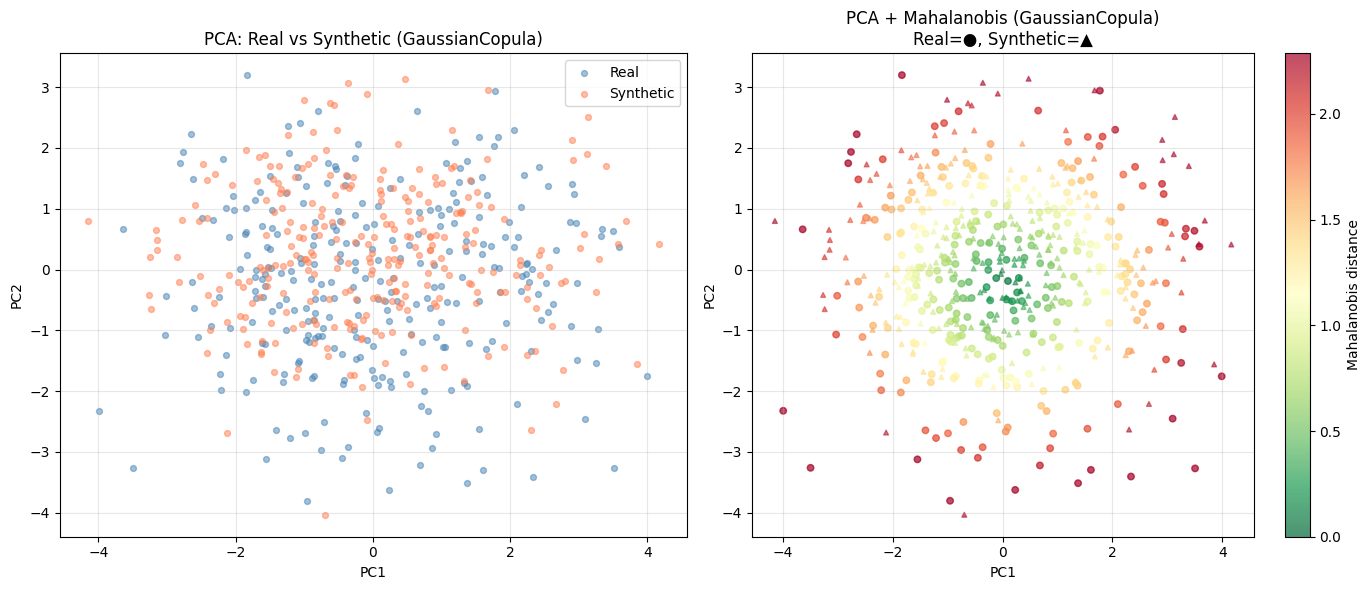

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.275128,1.068899,-0.206229
2,TVAE,1.282497,1.109717,-0.172779
3,GaussianCopula,1.276532,1.162520,-0.114012
1,CopulaGAN,1.253214,1.538513,0.285299


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [39]:
# print results on excel sheets 

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_AD.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            matched_df.to_excel(writer, sheet_name=model_name[:31], index=False)

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = ad_data.copy()
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_AD.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_AD.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [40]:
# MIA with ML regression model 

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "Group"
feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = ad_data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=float)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=float)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.7464664749057727, 'Advantage': np.float64(0.3802816901408451), 'TPR_at_FPR_001': np.float64(0.10915492957746478)}


In [41]:
# MIA with Mahalanobis 

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
X_train = ad_data[feature_cols].to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CopulaGAN,0.992722,0.947183,0.876761,3.02176,12.997282
1,CTGAN,0.981998,0.869718,0.697183,3.02176,11.027243
2,TVAE,0.817844,0.514085,0.028169,3.02176,5.437294
3,GaussianCopula,0.732828,0.390845,0.017606,3.02176,3.990131
